# NFHS-5 District Health Indicators Analysis

This notebook converts the markdown findings into a runnable analysis of
`output/data/raw_nfhs_5_district_health_indicators.csv`, with supporting
checks against the cleaned facility-health join output.

**Objective:** understand what the third dataset contains, where joins can
fail, and which district-level health indicators show useful planning
patterns for the hackathon app.


## Notebook plan

- Load the raw NFHS-5-style district health table and the cleaned
  facility-health table.
- Profile the row grain, keys, sample sizes, missingness, and join traps.
- Visualize join strategy distribution and major health-indicator groups.
- Build a transparent district `health_need_score` from selected adverse
  and access indicators.
- Surface state/district patterns and correlations that are useful for
  planning, while keeping the district-level nature of the data explicit.


In [1]:
from __future__ import annotations

from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "output" / "data" / "raw_nfhs_5_district_health_indicators.csv").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate output/data/raw_nfhs_5_district_health_indicators.csv from cwd")

DATA_DIR = ROOT / "output" / "data"
HEALTH_CSV = DATA_DIR / "raw_nfhs_5_district_health_indicators.csv"
CLEANED_CSV = DATA_DIR / "facility_health_cleaned.csv"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 130
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

health_raw = pd.read_csv(HEALTH_CSV)
facilities = pd.read_csv(CLEANED_CSV)

health = health_raw.copy()
health["district_clean"] = health["district_name"].astype(str).str.strip()
health["state_clean"] = health["state_ut"].astype(str).str.strip()

id_cols = {"district_name", "state_ut", "district_clean", "state_clean"}
for col in health.columns:
    if col not in id_cols:
        health[col] = pd.to_numeric(health[col], errors="coerce")

def normalize_text(value) -> str:
    if pd.isna(value):
        return ""
    value = str(value).strip().lower().replace("&", "and")
    return re.sub(r"[^a-z0-9]+", "", value)

def normalize_state(value) -> str:
    aliases = {
        "nctofdelhi": "delhi",
        "jammuandkashmir": "jammukashmir",
        "jammukashmir": "jammukashmir",
        "maharastra": "maharashtra",
        "maharashtra": "maharashtra",
        "odisha": "odisha",
        "orissa": "odisha",
        "dadraandnagarhavelianddamananddiu": "dadranagarhavelidamandiu",
    }
    raw = normalize_text(value)
    return aliases.get(raw, raw)

health["health_key"] = health["state_clean"].map(normalize_state) + "|" + health["district_clean"].map(normalize_text)
health.head(3)


/var/folders/n0/qltlkrkj3j7fvwdbktn46z5h0000gn/T/ipykernel_62628/2266440899.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  health["health_key"] = health["state_clean"].map(normalize_state) + "|" + health["district_clean"].map(normalize_text)


,district_name,state_ut,households_surveyed,women_15_49_interviewed,men_15_54_interviewed,female_population_age_6_years_and_above_ever_schooled_pct,population_below_age_15_years_pct,sex_ratio_total_f_per_1000_m,sex_ratio_at_birth_5y_f_per_1000_m,child_u5_whose_birth_was_civil_reg_pct,deaths_in_the_last_3_years_civil_reg_pct,hh_electricity_pct,hh_improved_water_pct,hh_use_improved_sanitation_pct,households_using_clean_fuel_for_cooking_pct,households_using_iodized_salt_pct,hh_member_covered_health_insurance_pct,child_5y_who_attended_pre_primary_school_during_the_school_pct,women_age_15_49_who_are_literate_pct,women_age_15_49_with_10_or_more_years_of_schooling_pct,w20_24_married_before_age_18_years_pct,births_in_the_5_years_preceding_the_survey_that_are_birth_3_pct,w15_19_who_were_already_mothers_or_pregnant_at_the_time_of_pct,w15_24_who_use_menstrual_hygiene_pct,fp_cm_w15_49_any_method_pct,fp_cm_w15_49_modern_method_pct,fp_cm_w15_49_f_steril_pct,fp_cm_w15_49_m_steril_pct,fp_cm_w15_49_iud_pct,fp_cm_w15_49_pill_pct,fp_cm_w15_49_condom_pct,fp_cm_w15_49_injectables_pct,fp_unmet_total_cm_w15_49_7_pct,fp_unmet_spacing_cm_w15_49_7_pct,health_worker_ever_talked_to_female_non_users_about_family_pct,current_users_ever_told_about_side_effects_of_current_metho_pct,mothers_who_had_an_anc_visit_in_the_first_trimester_lb5y_pct,mothers_who_had_at_least_4_anc_visits_lb5y_pct,mothers_whose_last_birth_was_protected_against_neo_tetanus_pct,mothers_who_consumed_ifa_for_100_days_or_more_when_they_wer_pct,...,child_u6m_exclusively_breastfed_pct,child_6_8m_receiving_solid_or_semi_solid_food_and_breastmil_pct,breastfeeding_child_6_23m_receiving_an_adequate_diet16_17_pct,non_breastfeeding_child_6_23m_receiving_an_adequate_diet16_pct,total_child_6_23m_receiving_an_adequate_diet16_17_pct,child_u5_who_are_stunted_height_for_age_18_pct,child_u5_who_are_wasted_weight_for_height_18_pct,child_u5_who_are_severe_wasted_weight_for_height_19_pct,child_u5_who_are_underweight_weight_for_age_18_pct,child_u5_who_are_overweight_weight_for_height_20_pct,women_age_15_49_years_whose_bmi_bmi_is_underweight_bmi_lt_1_pct,women_age_15_49_years_who_are_overweight_obese_bmi_gte_25_0_pct,women_age_15_49_years_who_have_high_risk_whr_gte_0_85_pct,child_6_59m_who_are_anaemic_lt_11_0_g_dl_22_pct,non_pregnant_w15_49_who_are_anaemic_lt_12_0_g_dl_22_pct,pregnant_w15_49_who_are_anaemic_lt_11_0_g_dl_22_pct,all_w15_49_who_are_anaemic_pct,all_w15_19_who_are_anaemic_pct,women_age_15_years_and_above_with_high_141_160_mg_dl_blood_pct,w15_plus_with_very_high_gt_160_mg_dl_blood_sugar_pct,w15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct,m15_plus_with_high_141_160_mg_dl_blood_sugar_pct,men_age_15_years_and_above_with_very_high_gt_160_mg_dl_bloo_pct,m15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct,w15_plus_with_mildly_high_bp_sys_140_159_mmhg_and_or_dia_90_pct,w15_plus_with_moderately_or_severely_high_bp_sys_gte_160_mm_pct,w15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct,m15_plus_with_mildly_high_bp_sys_140_159_mmhg_and_or_dia_90_pct,m15_plus_with_moderately_or_severely_high_bp_sys_gte_160_mm_pct,m15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct,women_age_30_49_years_ever_undergone_a_cervical_screen_pct,women_age_30_49_years_ever_undergone_a_breast_exam_pct,women_age_30_49_years_ever_undergone_an_oral_cancer_exam_pct,w15_plus_who_use_any_kind_of_tobacco_pct,m15_plus_who_use_any_kind_of_tobacco_pct,w15_plus_who_consume_alcohol_pct,m15_plus_who_consume_alcohol_pct,district_clean,state_clean,health_key
0,Nicobars,Andaman & Nicobar Islands,882.0,764.0,125.0,78.0,23.0,973.0,927.0,98.0,83.2,97.9,98.8,83.5,56.9,99.4,2.7,NaN,87.5,53.5,11.4,0.0,1.8,100.0,65.3,57.2,46.4,0.0,2.7,2.0,4.9,1.2,9.5,3.3,40.4,49.4,62.8,71.7,78.0,72.6,...,NaN,NaN,NaN,NaN,NaN,21.6,15.7,7.8,24.6,1.5,8.2,39.1,62.5,37.7,38.4,NaN,38.3,48.0,7.4,3.9,13.1,9.6,4.4,15.4,23.2,8.5,35.4,32.9,11.1,47.0,13.4,13.2,5.4,63.5,76.8,29.6,64.5,Nicobars,Andaman & Nicobar Islands,andamanandnicobari

## 1. High-level table profile

The raw health file is district-grain: one row per district/state pair.
It should be used as geographic context, not as a direct facility-level
measurement. When joined to facilities, every facility in a district
inherits the same district summary values.


,Metric,Value
0,Rows,706
1,Columns,109
2,States/UTs,36
3,Duplicate state + district keys,0
4,Columns with missing values,0
5,District names with trailing spaces,704
6,Median households surveyed,908
7,Median women 15-49 interviewed,1020
8,Median men 15-54 interviewed,145


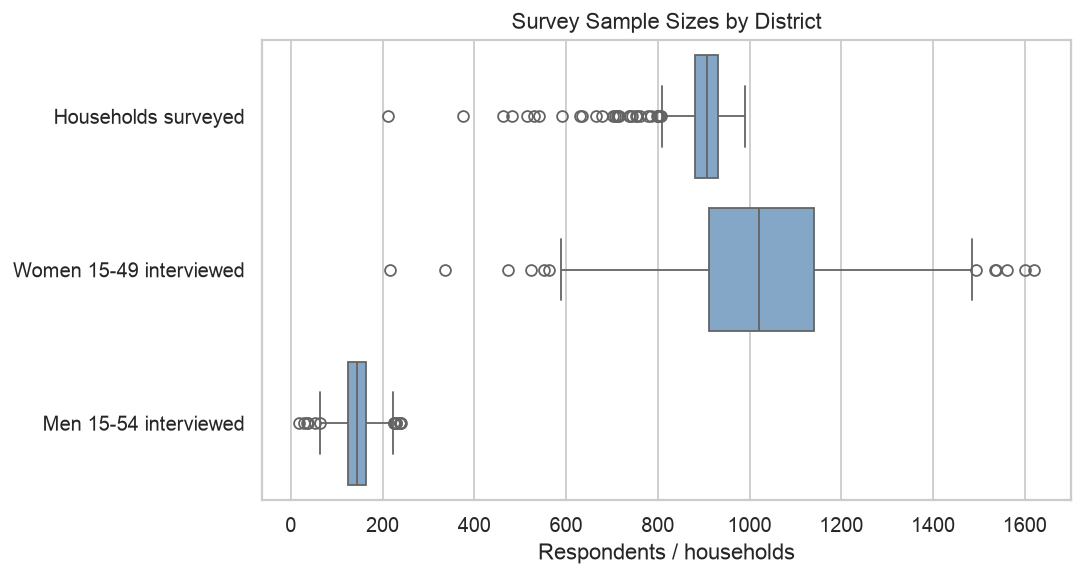

In [2]:
profile = pd.DataFrame(
    {
        "Metric": [
            "Rows",
            "Columns",
            "States/UTs",
            "Duplicate state + district keys",
            "Columns with missing values",
            "District names with trailing spaces",
            "Median households surveyed",
            "Median women 15-49 interviewed",
            "Median men 15-54 interviewed",
        ],
        "Value": [
            len(health_raw),
            health_raw.shape[1],
            health["state_clean"].nunique(),
            health_raw.duplicated(["state_ut", "district_name"]).sum(),
            int((health_raw.notna().mean() < 1).sum()),
            int(health_raw["district_name"].astype(str).str.endswith(" ").sum()),
            int(health["households_surveyed"].median()),
            int(health["women_15_49_interviewed"].median()),
            int(health["men_15_54_interviewed"].median()),
        ],
    }
)

display(profile)

sample_cols = [
    "households_surveyed",
    "women_15_49_interviewed",
    "men_15_54_interviewed",
]
sample_long = health[sample_cols].rename(
    columns={
        "households_surveyed": "Households surveyed",
        "women_15_49_interviewed": "Women 15-49 interviewed",
        "men_15_54_interviewed": "Men 15-54 interviewed",
    }
).melt(var_name="Sample", value_name="Respondents")

fig, ax = plt.subplots(figsize=(8.5, 4.6))
sns.boxplot(data=sample_long, y="Sample", x="Respondents", ax=ax, color="#79a7d3")
ax.set_title("Survey Sample Sizes by District")
ax.set_xlabel("Respondents / households")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 2. Join diagnostics and mapping traps

The health table has no pincode, facility ID, latitude, or longitude.
The practical bridge is:

`facility address_zipOrPostcode` -> extracted six-digit PIN ->
`pincode_bridge.csv` -> normalized state/district -> NFHS `state_ut` +
`district_name`.

The current cleaned facility output preserves join strategy and uncertainty
fields, which should stay visible in any user-facing app.


,join_strategy,facility_rows
0,pincode_district_state_exact,9032
1,pincode_only_no_health_match,397
2,facility_city_state_fallback,301
3,no_valid_pincode,150
4,pincode_district_state_fuzzy,131
5,unjoined,66


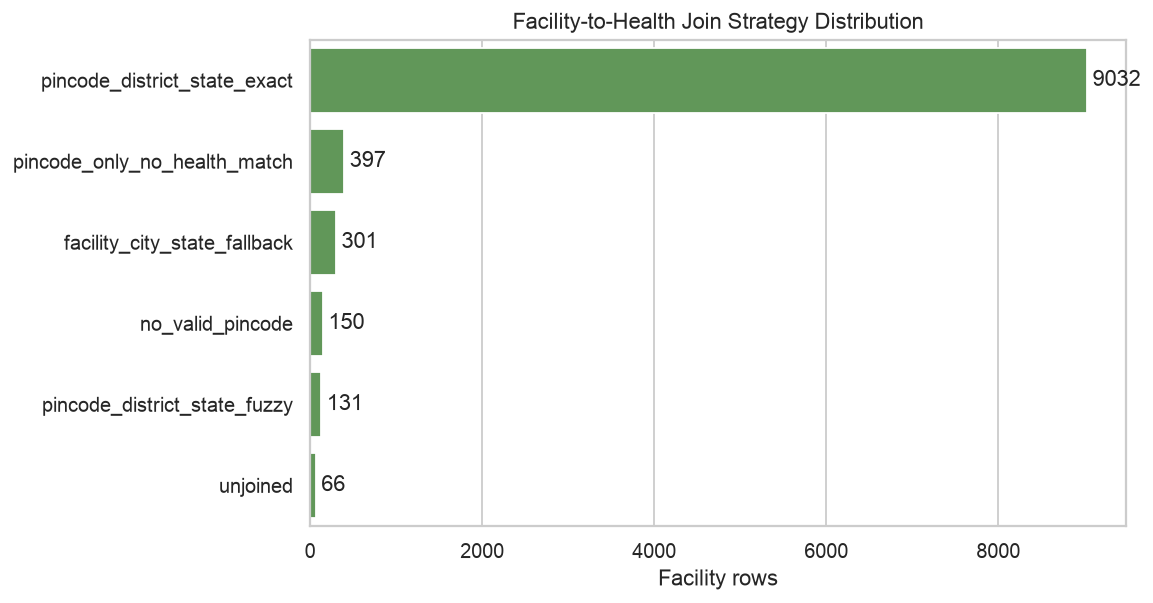

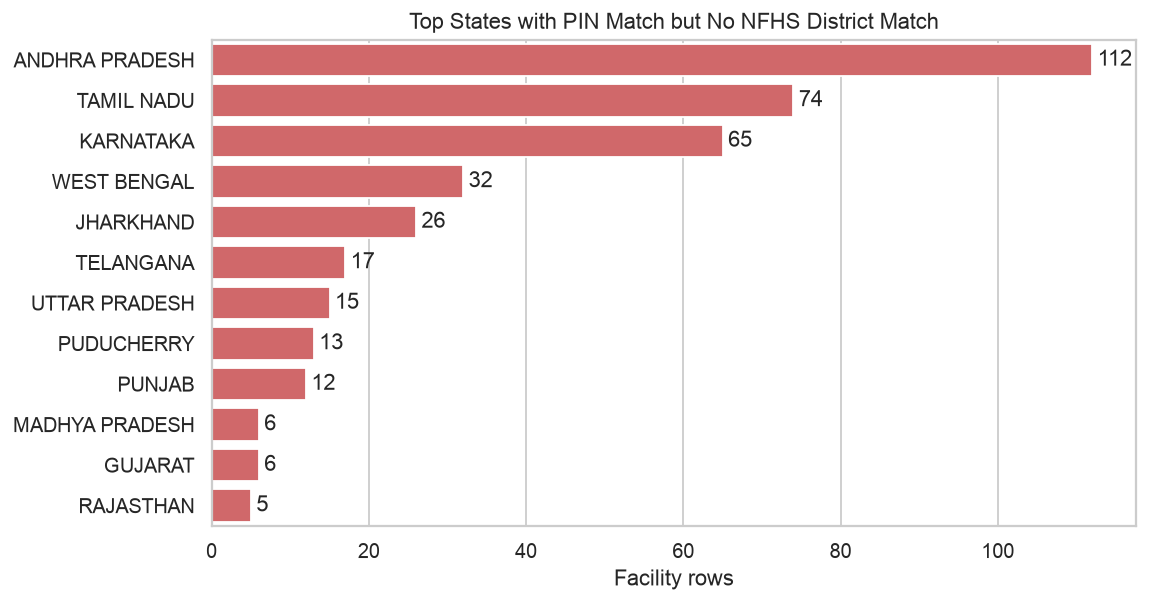

In [3]:
join_counts = (
    facilities["join_strategy"]
    .value_counts(dropna=False)
    .rename_axis("join_strategy")
    .reset_index(name="facility_rows")
)
display(join_counts)

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(data=join_counts, y="join_strategy", x="facility_rows", ax=ax, color="#59a14f")
ax.set_title("Facility-to-Health Join Strategy Distribution")
ax.set_xlabel("Facility rows")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt="%d")
plt.tight_layout()
plt.show()

no_health = facilities[facilities["join_strategy"].eq("pincode_only_no_health_match")].copy()
no_health_by_state = (
    no_health["pincode_primary_state"]
    .value_counts()
    .rename_axis("pincode_primary_state")
    .reset_index(name="facility_rows")
    .head(12)
)

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(data=no_health_by_state, y="pincode_primary_state", x="facility_rows", ax=ax, color="#e15759")
ax.set_title("Top States with PIN Match but No NFHS District Match")
ax.set_xlabel("Facility rows")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt="%d")
plt.tight_layout()
plt.show()


**Key join trap:** the raw NFHS table uses `Maharastra`, while the pincode
data uses `MAHARASHTRA`. Without an alias, a large number of Maharashtra
facility rows fail the health join even when pincode data is present.

District naming also needs a crosswalk for renamed or newly split districts:
examples include Gurgaon/Gurugram, Bangalore/Bengaluru Urban,
Darjiling/Darjeeling, Haora/Howrah, and newer Andhra Pradesh or Tamil Nadu
postal districts that do not appear as separate NFHS-5 rows.


In [4]:
state_values = pd.Series(sorted(health_raw["state_ut"].unique()), name="raw_state_ut")
display(state_values.to_frame().query("raw_state_ut.str.contains('Mahar|Lakshadweep', regex=True)", engine="python"))

maharashtra_gap = facilities[
    facilities["pincode_primary_state"].astype(str).str.contains("MAHAR", na=False)
    & facilities["join_strategy"].eq("pincode_only_no_health_match")
]
print(f"Maharashtra facility rows missing health indicators due to state/district join mismatch: {len(maharashtra_gap):,}")


,raw_state_ut
0,Lakshadweep
19,Maharastra


Maharashtra facility rows missing health indicators due to state/district join mismatch: 0


## 3. Indicator groups and selected summary statistics

Most columns ending in `_pct` are percentages. Exceptions to watch:
survey counts, sex ratios per 1,000 males, and out-of-pocket expenditure
per public-facility delivery.

The table covers household conditions, insurance, education, fertility and
family planning, maternal care, delivery care, child immunization, child
illness, infant feeding, nutrition, anaemia, NCD markers, cancer screening,
tobacco, and alcohol.


In [5]:
key_indicators = {
    "Health insurance coverage": "hh_member_covered_health_insurance_pct",
    "Women literate": "women_age_15_49_who_are_literate_pct",
    "Institutional births": "institutional_birth_5y_pct",
    "Skilled birth attendance": "births_attended_by_skilled_hp_5y_10_pct",
    "C-section deliveries": "births_delivered_by_csection_5y_pct",
    "Children fully vaccinated": "child_12_23m_fully_vaccinated_based_on_information_from_vax_pct",
    "Child adequate diet 6-23m": "total_child_6_23m_receiving_an_adequate_diet16_17_pct",
    "U5 stunted": "child_u5_who_are_stunted_height_for_age_18_pct",
    "U5 wasted": "child_u5_who_are_wasted_weight_for_height_18_pct",
    "U5 underweight": "child_u5_who_are_underweight_weight_for_age_18_pct",
    "Women 15-49 anaemic": "all_w15_49_who_are_anaemic_pct",
    "Women high BP": "w15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct",
    "Men high BP": "m15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct",
    "Women high/very high blood sugar": "w15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct",
    "Men high/very high blood sugar": "m15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct",
    "Cervical screening": "women_age_30_49_years_ever_undergone_a_cervical_screen_pct",
    "Breast exam": "women_age_30_49_years_ever_undergone_a_breast_exam_pct",
    "Oral cancer exam": "women_age_30_49_years_ever_undergone_an_oral_cancer_exam_pct",
    "Women tobacco": "w15_plus_who_use_any_kind_of_tobacco_pct",
    "Men tobacco": "m15_plus_who_use_any_kind_of_tobacco_pct",
    "Women alcohol": "w15_plus_who_consume_alcohol_pct",
    "Men alcohol": "m15_plus_who_consume_alcohol_pct",
}

rows = []
for label, col in key_indicators.items():
    s = health[col]
    min_idx, max_idx = s.idxmin(), s.idxmax()
    rows.append(
        {
            "Indicator": label,
            "Mean": round(s.mean(), 1),
            "Median": round(s.median(), 1),
            "P10": round(s.quantile(0.10), 1),
            "P90": round(s.quantile(0.90), 1),
            "Min district": f"{health.loc[min_idx, 'district_clean']}, {health.loc[min_idx, 'state_clean']} ({s.loc[min_idx]:.1f})",
            "Max district": f"{health.loc[max_idx, 'district_clean']}, {health.loc[max_idx, 'state_clean']} ({s.loc[max_idx]:.1f})",
        }
    )
indicator_summary = pd.DataFrame(rows)
display(indicator_summary)


,Indicator,Mean,Median,P10,P90,Min district,Max district
0,Health insurance coverage,40.2,35.7,13.2,72.2,"South Andaman, Andaman & Nicobar Islands (1.2)","Barmer, Rajasthan (97.8)"
1,Women literate,74.3,75.1,57.7,89.0,"Jhabua, Madhya Pradesh (38.6)","Kottayam, Kerala (99.7)"
2,Institutional births,88.7,92.2,73.8,99.4,"Mon, Nagaland (21.4)","South Goa, Goa (100.0)"
3,Skilled birth attendance,89.6,92.3,77.6,99.0,"Mon, Nagaland (30.9)","Sri Potti Sriramulu Nello, Andhra Pradesh (100.0)"
4,C-section deliveries,22.8,18.6,6.6,46.8,"Mon, Nagaland (1.4)","Karimnagar, Telangana (82.4)"
5,Children fully vaccinated,82.6,83.6,69.4,94.0,"Ukhrul, Manipur (45.0)","Kupwara, Jammu & Kashmir (100.0)"
6,Child adequate diet 6-23m,11.9,10.6,4.0,22.0,"Mahesana, Gujarat (0.0)","East Garo Hills, Meghalaya (43.9)"
7,U5 stunted,33.5,32.9,23.1,45.1,"Jagatsinghapur, Odisha (13.2)","Pashchimi Singhbhum, Jharkhand (60.6)"
8,U5 wasted,18.5,18.1,10.3,27.3,"North District, Sikkim (4.5)","Karimganj, Assam (48.0)"
9,U5 underweight,29.5,29.3,16.8,42.3,"South District, Sikkim (7.2)","Pashchimi Singhbhum, Jharkhand (62.4)"


## 4. Visual trends across major health domains

These plots are unweighted district-level distributions. They are useful
for comparing district patterns, but not for producing official national
estimates.


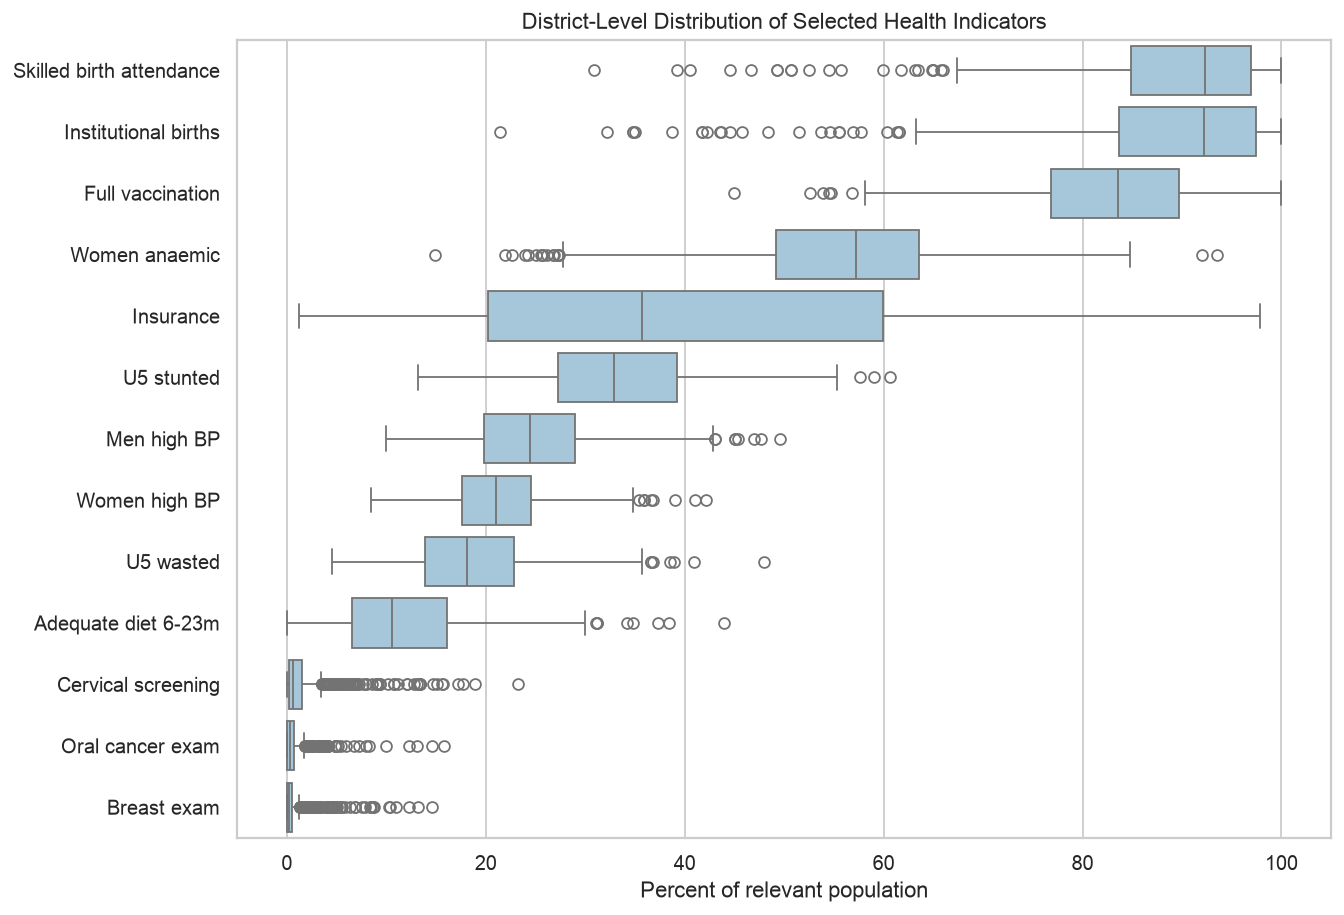

In [6]:
domain_cols = {
    "Insurance": "hh_member_covered_health_insurance_pct",
    "Institutional births": "institutional_birth_5y_pct",
    "Skilled birth attendance": "births_attended_by_skilled_hp_5y_10_pct",
    "Full vaccination": "child_12_23m_fully_vaccinated_based_on_information_from_vax_pct",
    "Adequate diet 6-23m": "total_child_6_23m_receiving_an_adequate_diet16_17_pct",
    "U5 stunted": "child_u5_who_are_stunted_height_for_age_18_pct",
    "U5 wasted": "child_u5_who_are_wasted_weight_for_height_18_pct",
    "Women anaemic": "all_w15_49_who_are_anaemic_pct",
    "Women high BP": "w15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct",
    "Men high BP": "m15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct",
    "Cervical screening": "women_age_30_49_years_ever_undergone_a_cervical_screen_pct",
    "Breast exam": "women_age_30_49_years_ever_undergone_a_breast_exam_pct",
    "Oral cancer exam": "women_age_30_49_years_ever_undergone_an_oral_cancer_exam_pct",
}
domain_long = health[list(domain_cols.values())].rename(columns={v: k for k, v in domain_cols.items()}).melt(
    var_name="Indicator", value_name="District percent"
)

order = (
    domain_long.groupby("Indicator")["District percent"]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(10.5, 7.2))
sns.boxplot(data=domain_long, y="Indicator", x="District percent", order=order, ax=ax, color="#9ecae1")
ax.set_title("District-Level Distribution of Selected Health Indicators")
ax.set_xlabel("Percent of relevant population")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


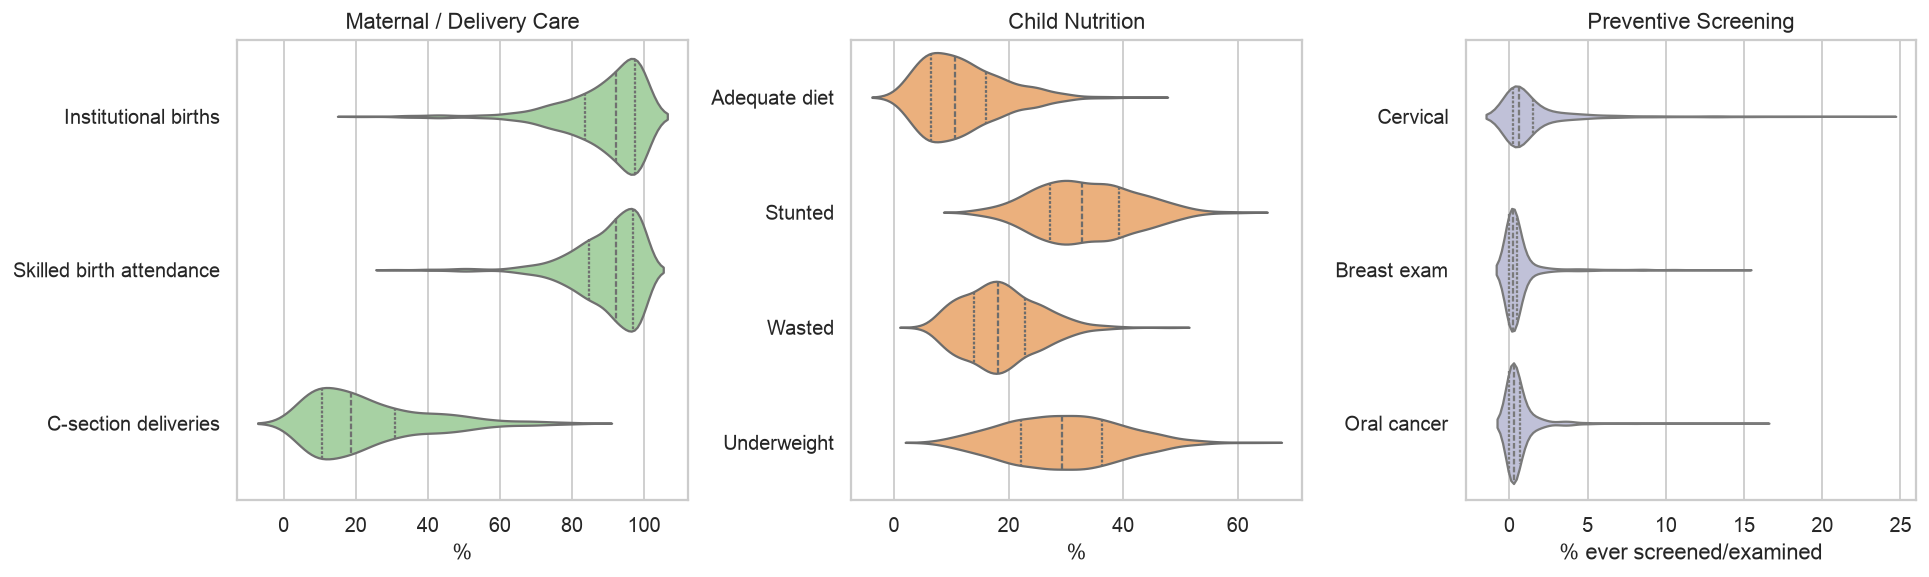

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

maternal = health[
    [
        "institutional_birth_5y_pct",
        "births_attended_by_skilled_hp_5y_10_pct",
        "births_delivered_by_csection_5y_pct",
    ]
].rename(
    columns={
        "institutional_birth_5y_pct": "Institutional births",
        "births_attended_by_skilled_hp_5y_10_pct": "Skilled birth attendance",
        "births_delivered_by_csection_5y_pct": "C-section deliveries",
    }
).melt(var_name="Indicator", value_name="District percent")
sns.violinplot(data=maternal, y="Indicator", x="District percent", ax=axes[0], color="#a1d99b", inner="quartile")
axes[0].set_title("Maternal / Delivery Care")
axes[0].set_xlabel("%")
axes[0].set_ylabel("")

nutrition = health[
    [
        "total_child_6_23m_receiving_an_adequate_diet16_17_pct",
        "child_u5_who_are_stunted_height_for_age_18_pct",
        "child_u5_who_are_wasted_weight_for_height_18_pct",
        "child_u5_who_are_underweight_weight_for_age_18_pct",
    ]
].rename(
    columns={
        "total_child_6_23m_receiving_an_adequate_diet16_17_pct": "Adequate diet",
        "child_u5_who_are_stunted_height_for_age_18_pct": "Stunted",
        "child_u5_who_are_wasted_weight_for_height_18_pct": "Wasted",
        "child_u5_who_are_underweight_weight_for_age_18_pct": "Underweight",
    }
).melt(var_name="Indicator", value_name="District percent")
sns.violinplot(data=nutrition, y="Indicator", x="District percent", ax=axes[1], color="#fdae6b", inner="quartile")
axes[1].set_title("Child Nutrition")
axes[1].set_xlabel("%")
axes[1].set_ylabel("")

screening = health[
    [
        "women_age_30_49_years_ever_undergone_a_cervical_screen_pct",
        "women_age_30_49_years_ever_undergone_a_breast_exam_pct",
        "women_age_30_49_years_ever_undergone_an_oral_cancer_exam_pct",
    ]
].rename(
    columns={
        "women_age_30_49_years_ever_undergone_a_cervical_screen_pct": "Cervical",
        "women_age_30_49_years_ever_undergone_a_breast_exam_pct": "Breast exam",
        "women_age_30_49_years_ever_undergone_an_oral_cancer_exam_pct": "Oral cancer",
    }
).melt(var_name="Indicator", value_name="District percent")
sns.violinplot(data=screening, y="Indicator", x="District percent", ax=axes[2], color="#bcbddc", inner="quartile")
axes[2].set_title("Preventive Screening")
axes[2].set_xlabel("% ever screened/examined")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()


## 5. Health-need score

The score below mirrors the cleaned dataset's approach: percentile-rank
adverse indicators upward and access indicators downward, then average the
components. It is intentionally transparent and bounded, but it is a
planning proxy, not an official risk model.


/var/folders/n0/qltlkrkj3j7fvwdbktn46z5h0000gn/T/ipykernel_62628/2272448525.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  health["health_need_score"] = pd.concat(score_parts, axis=1).mean(axis=1).clip(0, 1)


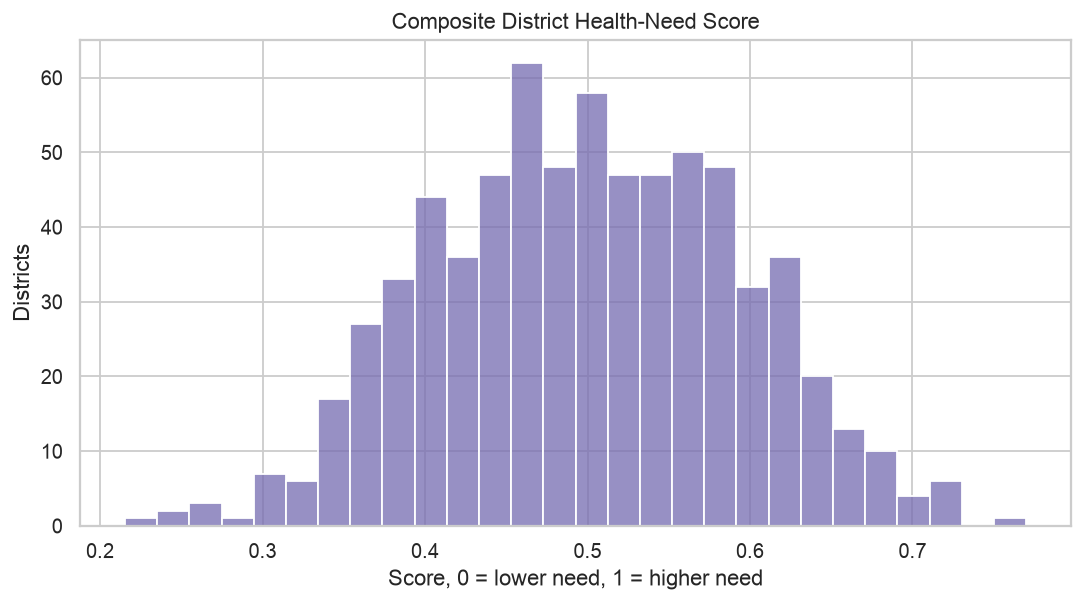

,district_clean,state_clean,health_need_score,all_w15_49_who_are_anaemic_pct,institutional_birth_5y_pct,hh_member_covered_health_insurance_pct,w15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct,m15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct
78,Katihar,Bihar,0.770,68.400000,66.900000,8.400000,17.000000,17.800000
690,Uttar Dinajpur,West Bengal,0.730,72.400000,76.900000,21.000000,16.300000,23.800000
234,Pakur,Jharkhand,0.730,79.700000,64.600000,52.500000,17.100000,20.200000
597,Unakoti,Tripura,0.725,67.900000,71.500000,28.000000,21.000000,22.100000
165,Kheda,Gujarat,0.715,76.100000,95.200000,32.200000,24.000000,24.500000
440,Kendujhar,Odisha,0.714,69.200000,80.400000,43.300000,24.100000,25.100000
155,Tapi,Gujarat,0.711,77.400000,92.900000,42.300000,25.200000,28.000000
416,Wokha,Nagaland,0.705,30.900000,43.600000,20.600000,24.300000,35.700000
72,Sitamarhi,Bihar,0.704,61.700000,64.400000,20.700000,17.800000,17.900000
104,Jamui,Bihar,0.701,75.200000,73.400000,14.300000,12.600000,14.800000


In [8]:
high_bad = [
    "all_w15_49_who_are_anaemic_pct",
    "w15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct",
    "m15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct",
    "w15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct",
    "m15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct",
]
low_bad = [
    "hh_member_covered_health_insurance_pct",
    "women_age_15_49_who_are_literate_pct",
    "institutional_birth_5y_pct",
    "births_attended_by_skilled_hp_5y_10_pct",
    "women_age_30_49_years_ever_undergone_a_cervical_screen_pct",
    "women_age_30_49_years_ever_undergone_a_breast_exam_pct",
    "women_age_30_49_years_ever_undergone_an_oral_cancer_exam_pct",
]

score_parts = [health[col].rank(pct=True) for col in high_bad]
score_parts.extend([1 - health[col].rank(pct=True) for col in low_bad])
health["health_need_score"] = pd.concat(score_parts, axis=1).mean(axis=1).clip(0, 1)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.histplot(health["health_need_score"], bins=28, ax=ax, color="#756bb1")
ax.set_title("Composite District Health-Need Score")
ax.set_xlabel("Score, 0 = lower need, 1 = higher need")
ax.set_ylabel("Districts")
plt.tight_layout()
plt.show()

top_need = health.sort_values("health_need_score", ascending=False)[
    [
        "district_clean",
        "state_clean",
        "health_need_score",
        "all_w15_49_who_are_anaemic_pct",
        "institutional_birth_5y_pct",
        "hh_member_covered_health_insurance_pct",
        "w15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct",
        "m15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct",
    ]
].head(12)
display(top_need.style.format({"health_need_score": "{:.3f}"}))


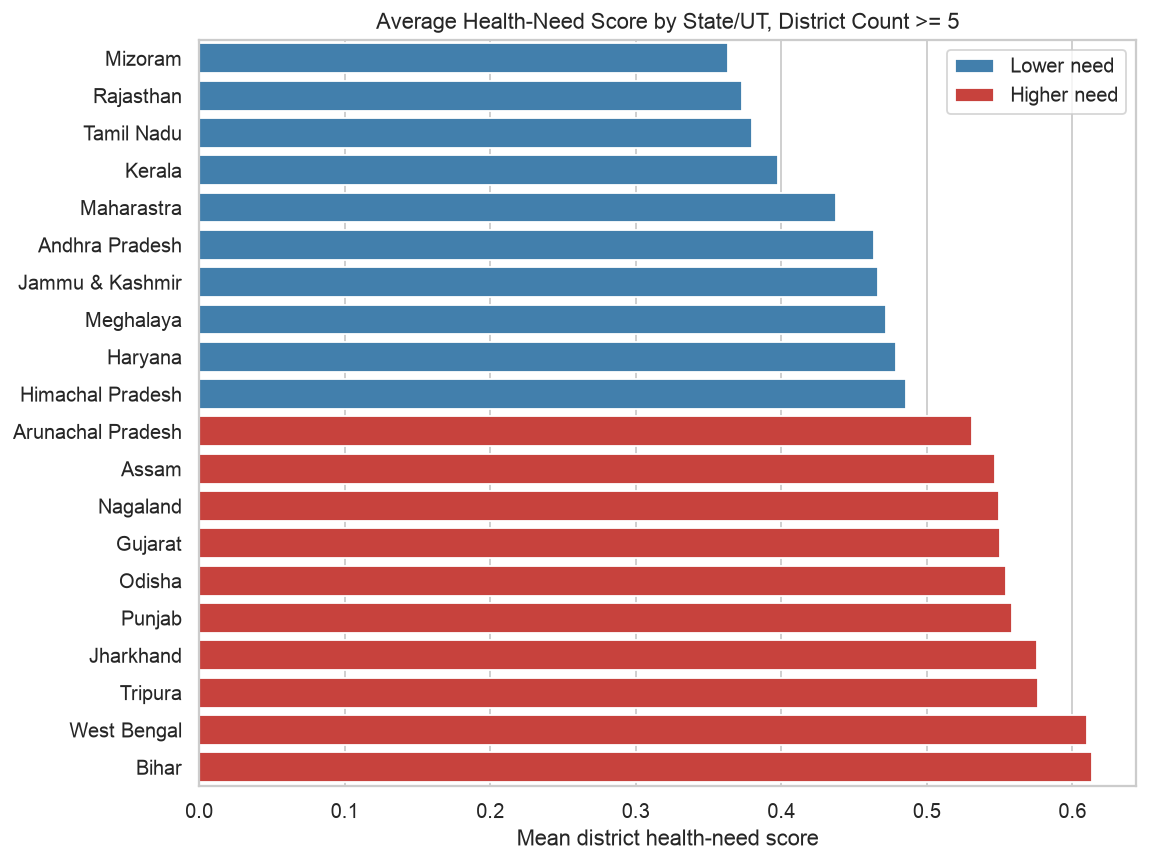

,state_clean,districts,health_need_score,anaemia,institutional_births,insurance,women_high_bp,men_high_bp
0,Bihar,38,0.613,64.7,77.8,14.1,15.436842,17.878947
1,West Bengal,19,0.610,71.5,92.0,28.9,20.457895,20.705263
2,Tripura,8,0.576,67.0,88.2,34.0,19.987500,21.600000
3,Jharkhand,24,0.576,66.3,76.2,51.8,17.241667,21.987500
4,Punjab,22,0.558,58.8,94.9,25.0,30.877273,37.259091
5,Odisha,30,0.555,64.3,92.4,48.3,22.006667,25.060000
6,Gujarat,33,0.551,64.6,93.1,40.6,20.184848,20.081818
7,Nagaland,11,0.549,29.2,43.3,21.1,22.672727,30.109091
8,Assam,33,0.547,65.7,85.1,61.0,19.296970,21.330303
9,Arunachal Pradesh,20,0.531,38.9,80.0,28.3,24.970000,33.420000


In [9]:
state_need = (
    health.groupby("state_clean")
    .agg(
        districts=("district_clean", "size"),
        health_need_score=("health_need_score", "mean"),
        anaemia=("all_w15_49_who_are_anaemic_pct", "mean"),
        institutional_births=("institutional_birth_5y_pct", "mean"),
        insurance=("hh_member_covered_health_insurance_pct", "mean"),
        women_high_bp=("w15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct", "mean"),
        men_high_bp=("m15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct", "mean"),
    )
    .query("districts >= 5")
    .sort_values("health_need_score", ascending=False)
    .reset_index()
)

state_plot = pd.concat([state_need.head(10), state_need.tail(10)]).drop_duplicates("state_clean")
state_plot["group"] = np.where(
    state_plot["health_need_score"] >= state_need["health_need_score"].median(),
    "Higher need",
    "Lower need",
)

fig, ax = plt.subplots(figsize=(9, 6.8))
sns.barplot(
    data=state_plot.sort_values("health_need_score", ascending=True),
    y="state_clean",
    x="health_need_score",
    hue="group",
    dodge=False,
    palette={"Higher need": "#de2d26", "Lower need": "#3182bd"},
    ax=ax,
)
ax.set_title("Average Health-Need Score by State/UT, District Count >= 5")
ax.set_xlabel("Mean district health-need score")
ax.set_ylabel("")
ax.legend(title="")
plt.tight_layout()
plt.show()

display(state_need.head(10).style.format({"health_need_score": "{:.3f}", "anaemia": "{:.1f}", "institutional_births": "{:.1f}", "insurance": "{:.1f}"}))


## 6. Correlations worth noticing

These correlations are descriptive. They help identify planning gradients
and clusters of need, but they do not establish causality.


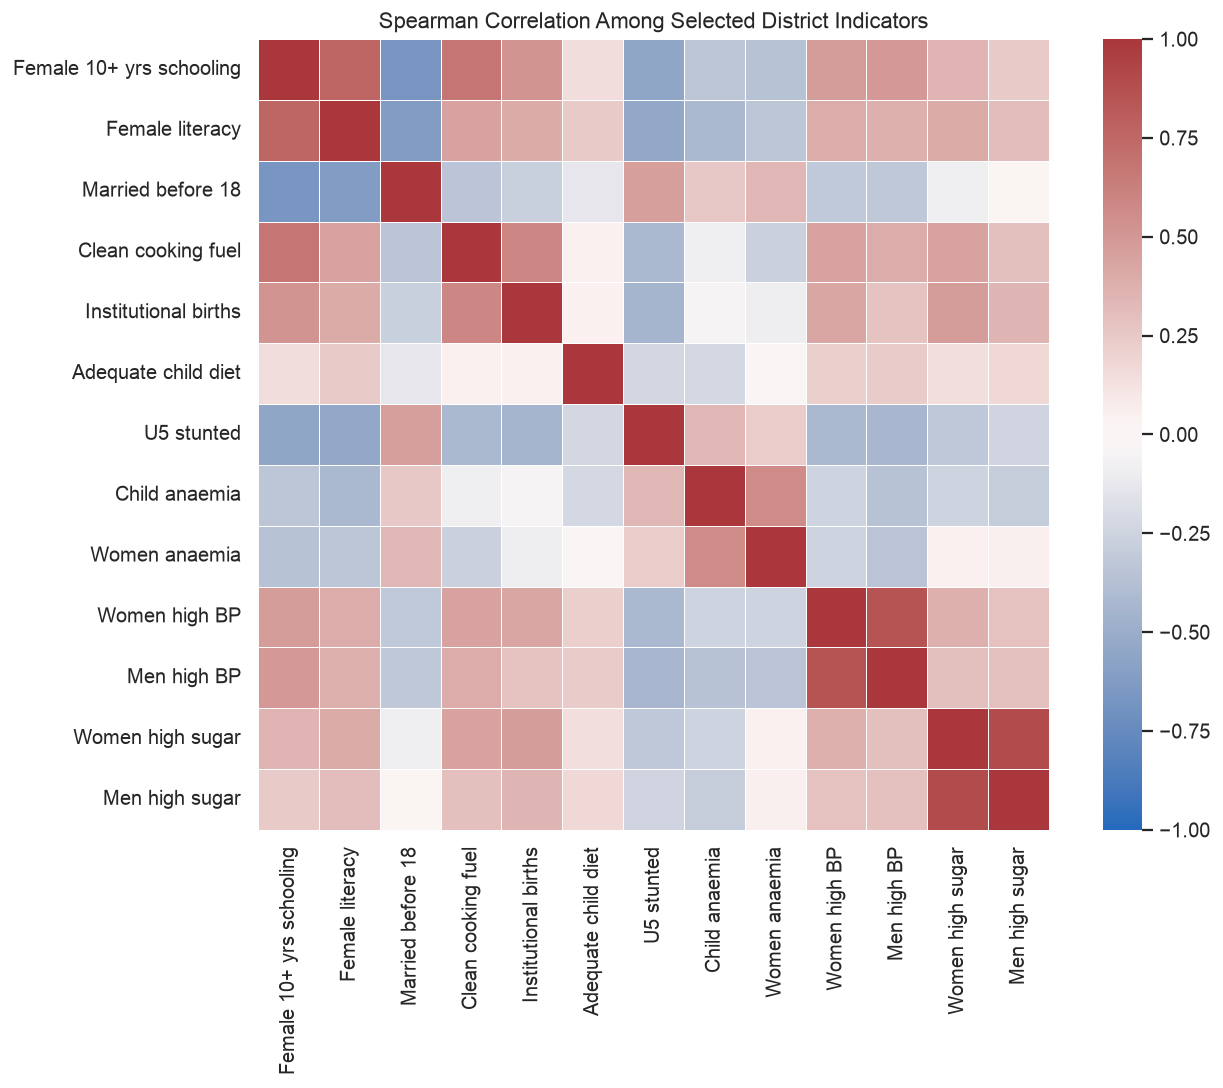

,Pair,Pearson,Spearman
0,Female 10+ yrs schooling vs married before 18,-0.65,-0.67
1,Clean cooking fuel vs institutional births,0.53,0.59
2,Women's anaemia vs child anaemia,0.65,0.56
3,Women high BP vs men high BP,0.86,0.86
4,Women high sugar vs men high sugar,0.91,0.90


In [10]:
corr_cols = {
    "Female 10+ yrs schooling": "women_age_15_49_with_10_or_more_years_of_schooling_pct",
    "Female literacy": "women_age_15_49_who_are_literate_pct",
    "Married before 18": "w20_24_married_before_age_18_years_pct",
    "Clean cooking fuel": "households_using_clean_fuel_for_cooking_pct",
    "Institutional births": "institutional_birth_5y_pct",
    "Adequate child diet": "total_child_6_23m_receiving_an_adequate_diet16_17_pct",
    "U5 stunted": "child_u5_who_are_stunted_height_for_age_18_pct",
    "Child anaemia": "child_6_59m_who_are_anaemic_lt_11_0_g_dl_22_pct",
    "Women anaemia": "all_w15_49_who_are_anaemic_pct",
    "Women high BP": "w15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct",
    "Men high BP": "m15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct",
    "Women high sugar": "w15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct",
    "Men high sugar": "m15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct",
}

corr_input = health[list(corr_cols.values())].rename(columns={v: k for k, v in corr_cols.items()})
corr = corr_input.rank().corr(method="pearson")

def spearman_corr(left: pd.Series, right: pd.Series) -> float:
    return left.rank().corr(right.rank())

fig, ax = plt.subplots(figsize=(10.5, 8.5))
sns.heatmap(corr, vmin=-1, vmax=1, center=0, cmap="vlag", annot=False, square=True, linewidths=0.4, ax=ax)
ax.set_title("Spearman Correlation Among Selected District Indicators")
plt.tight_layout()
plt.show()

selected_pairs = pd.DataFrame(
    [
        {
            "Pair": "Female 10+ yrs schooling vs married before 18",
            "Pearson": health["women_age_15_49_with_10_or_more_years_of_schooling_pct"].corr(health["w20_24_married_before_age_18_years_pct"]),
            "Spearman": spearman_corr(health["women_age_15_49_with_10_or_more_years_of_schooling_pct"], health["w20_24_married_before_age_18_years_pct"]),
        },
        {
            "Pair": "Clean cooking fuel vs institutional births",
            "Pearson": health["households_using_clean_fuel_for_cooking_pct"].corr(health["institutional_birth_5y_pct"]),
            "Spearman": spearman_corr(health["households_using_clean_fuel_for_cooking_pct"], health["institutional_birth_5y_pct"]),
        },
        {
            "Pair": "Women's anaemia vs child anaemia",
            "Pearson": health["all_w15_49_who_are_anaemic_pct"].corr(health["child_6_59m_who_are_anaemic_lt_11_0_g_dl_22_pct"]),
            "Spearman": spearman_corr(health["all_w15_49_who_are_anaemic_pct"], health["child_6_59m_who_are_anaemic_lt_11_0_g_dl_22_pct"]),
        },
        {
            "Pair": "Women high BP vs men high BP",
            "Pearson": health["w15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct"].corr(health["m15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct"]),
            "Spearman": spearman_corr(health["w15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct"], health["m15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct"]),
        },
        {
            "Pair": "Women high sugar vs men high sugar",
            "Pearson": health["w15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct"].corr(health["m15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct"]),
            "Spearman": spearman_corr(health["w15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct"], health["m15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct"]),
        },
    ]
)
display(selected_pairs.style.format({"Pearson": "{:.2f}", "Spearman": "{:.2f}"}))


## 7. Top condition or factor per district

This section turns a broad table into a district-level problem label.
Each candidate metric is converted into a **severity percentile** where
higher means worse:

- For adverse indicators, such as anaemia or high blood pressure, higher
  raw values are worse.
- For access or protective indicators, such as institutional births,
  insurance, sanitation, and screening, lower raw values are worse.

The top condition/factor for a district is the metric with the highest
severity percentile in that district. This is a triage label, not a
diagnosis or causal explanation.


In [11]:
condition_specs = [
    {"condition": "Women anaemia", "category": "Anaemia", "column": "all_w15_49_who_are_anaemic_pct", "direction": "high_bad"},
    {"condition": "Child anaemia", "category": "Anaemia", "column": "child_6_59m_who_are_anaemic_lt_11_0_g_dl_22_pct", "direction": "high_bad"},
    {"condition": "Child stunting", "category": "Child nutrition", "column": "child_u5_who_are_stunted_height_for_age_18_pct", "direction": "high_bad"},
    {"condition": "Child wasting", "category": "Child nutrition", "column": "child_u5_who_are_wasted_weight_for_height_18_pct", "direction": "high_bad"},
    {"condition": "Child underweight", "category": "Child nutrition", "column": "child_u5_who_are_underweight_weight_for_age_18_pct", "direction": "high_bad"},
    {"condition": "Poor child diet", "category": "Child nutrition", "column": "total_child_6_23m_receiving_an_adequate_diet16_17_pct", "direction": "low_bad"},
    {"condition": "Low institutional births", "category": "Maternal access", "column": "institutional_birth_5y_pct", "direction": "low_bad"},
    {"condition": "Low skilled birth attendance", "category": "Maternal access", "column": "births_attended_by_skilled_hp_5y_10_pct", "direction": "low_bad"},
    {"condition": "High C-section rate", "category": "Maternal access", "column": "births_delivered_by_csection_5y_pct", "direction": "high_bad"},
    {"condition": "Women high BP", "category": "NCD", "column": "w15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct", "direction": "high_bad"},
    {"condition": "Men high BP", "category": "NCD", "column": "m15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct", "direction": "high_bad"},
    {"condition": "Women high blood sugar", "category": "NCD", "column": "w15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct", "direction": "high_bad"},
    {"condition": "Men high blood sugar", "category": "NCD", "column": "m15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct", "direction": "high_bad"},
    {"condition": "Low cervical screening", "category": "Preventive screening", "column": "women_age_30_49_years_ever_undergone_a_cervical_screen_pct", "direction": "low_bad"},
    {"condition": "Low breast exam", "category": "Preventive screening", "column": "women_age_30_49_years_ever_undergone_a_breast_exam_pct", "direction": "low_bad"},
    {"condition": "Low oral cancer exam", "category": "Preventive screening", "column": "women_age_30_49_years_ever_undergone_an_oral_cancer_exam_pct", "direction": "low_bad"},
    {"condition": "Men tobacco use", "category": "Risk behavior", "column": "m15_plus_who_use_any_kind_of_tobacco_pct", "direction": "high_bad"},
    {"condition": "Women tobacco use", "category": "Risk behavior", "column": "w15_plus_who_use_any_kind_of_tobacco_pct", "direction": "high_bad"},
    {"condition": "Men alcohol use", "category": "Risk behavior", "column": "m15_plus_who_consume_alcohol_pct", "direction": "high_bad"},
    {"condition": "Women alcohol use", "category": "Risk behavior", "column": "w15_plus_who_consume_alcohol_pct", "direction": "high_bad"},
    {"condition": "Low health insurance", "category": "Socioeconomic / access", "column": "hh_member_covered_health_insurance_pct", "direction": "low_bad"},
    {"condition": "Low female literacy", "category": "Socioeconomic / access", "column": "women_age_15_49_who_are_literate_pct", "direction": "low_bad"},
    {"condition": "Low women 10+ yrs schooling", "category": "Socioeconomic / access", "column": "women_age_15_49_with_10_or_more_years_of_schooling_pct", "direction": "low_bad"},
    {"condition": "Low improved sanitation", "category": "Socioeconomic / access", "column": "hh_use_improved_sanitation_pct", "direction": "low_bad"},
    {"condition": "Low clean cooking fuel", "category": "Socioeconomic / access", "column": "households_using_clean_fuel_for_cooking_pct", "direction": "low_bad"},
]

spec_df = pd.DataFrame(condition_specs)
severity_frames = {}
burden_frames = {}

for spec in condition_specs:
    label = spec["condition"]
    col = spec["column"]
    raw = health[col]
    if spec["direction"] == "high_bad":
        severity = raw.rank(pct=True)
        burden = raw
    else:
        severity = (-raw).rank(pct=True)
        burden = 100 - raw
    severity_frames[label] = severity
    burden_frames[label] = burden.clip(lower=0, upper=100)

severity_matrix = pd.DataFrame(severity_frames)
burden_matrix = pd.DataFrame(burden_frames)

top_condition = severity_matrix.idxmax(axis=1)
top_severity = severity_matrix.max(axis=1)
top_burden = pd.Series(
    [burden_matrix.loc[idx, condition] for idx, condition in top_condition.items()],
    index=burden_matrix.index,
)

top_conditions_by_district = health[["district_clean", "state_clean", "health_need_score"]].copy()
top_conditions_by_district["top_condition_or_factor"] = top_condition
top_conditions_by_district["top_category"] = top_condition.map(spec_df.set_index("condition")["category"])
top_conditions_by_district["top_severity_percentile"] = top_severity
top_conditions_by_district["top_burden_or_gap_pct"] = top_burden

display(
    top_conditions_by_district.sort_values(
        ["health_need_score", "top_severity_percentile"], ascending=False
    )
    .head(20)
    .style.format(
        {
            "health_need_score": "{:.3f}",
            "top_severity_percentile": "{:.2f}",
            "top_burden_or_gap_pct": "{:.1f}",
        }
    )
)


,district_clean,state_clean,health_need_score,top_condition_or_factor,top_category,top_severity_percentile,top_burden_or_gap_pct
78,Katihar,Bihar,0.770,Child underweight,Child nutrition,0.98,48.1
690,Uttar Dinajpur,West Bengal,0.730,Women anaemia,Anaemia,0.93,72.4
234,Pakur,Jharkhand,0.730,Low women 10+ yrs schooling,Socioeconomic / access,1.00,86.4
597,Unakoti,Tripura,0.725,Women tobacco use,Risk behavior,0.99,54.9
165,Kheda,Gujarat,0.715,Poor child diet,Child nutrition,0.99,98.8
440,Kendujhar,Odisha,0.714,Men tobacco use,Risk behavior,0.97,64.2
155,Tapi,Gujarat,0.711,Child wasting,Child nutrition,0.99,36.6
416,Wokha,Nagaland,0.705,Low institutional births,Maternal access,0.99,56.4
72,Sitamarhi,Bihar,0.704,Child stunting,Child nutrition,0.99,54.2
104,Jamui,Bihar,0.701,Low improved sanitation,Socioeconomic / access,0.99,62.4


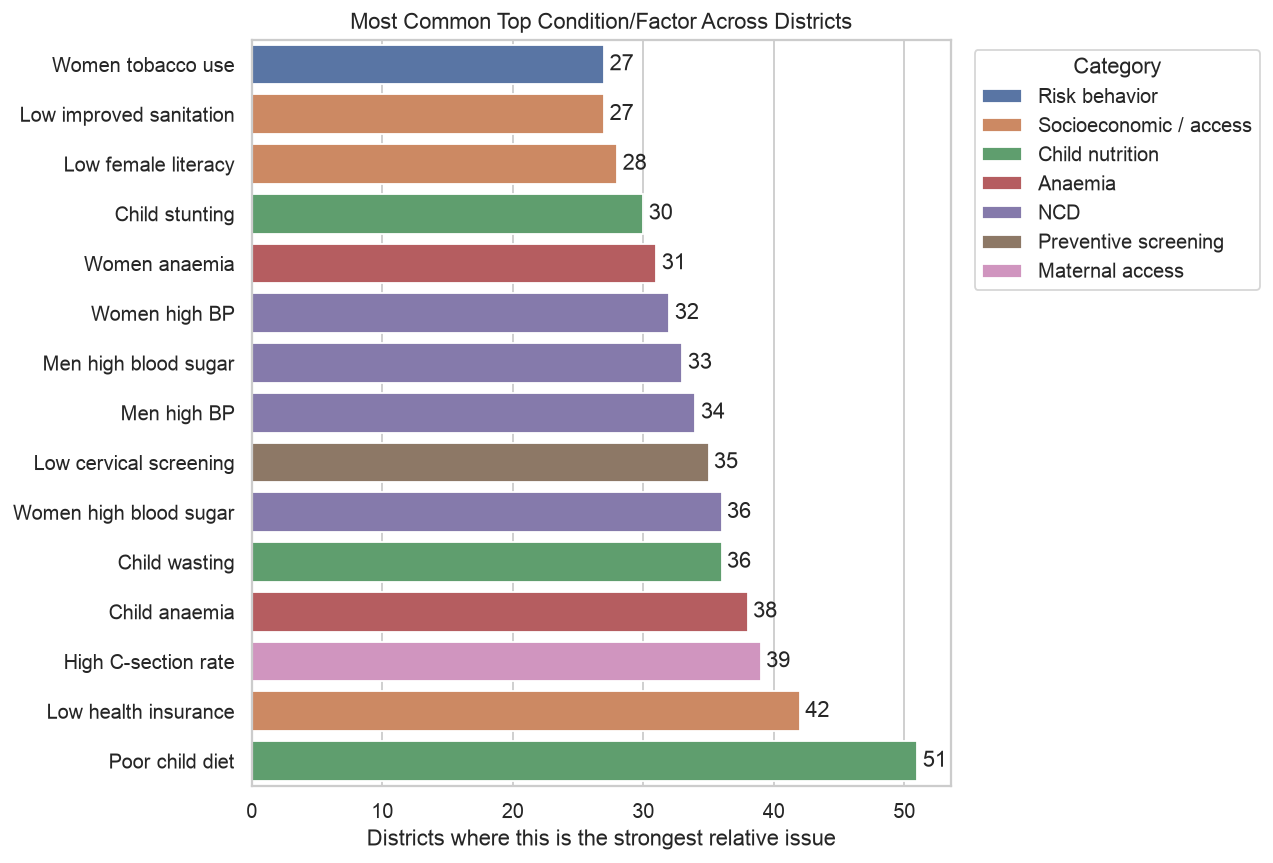

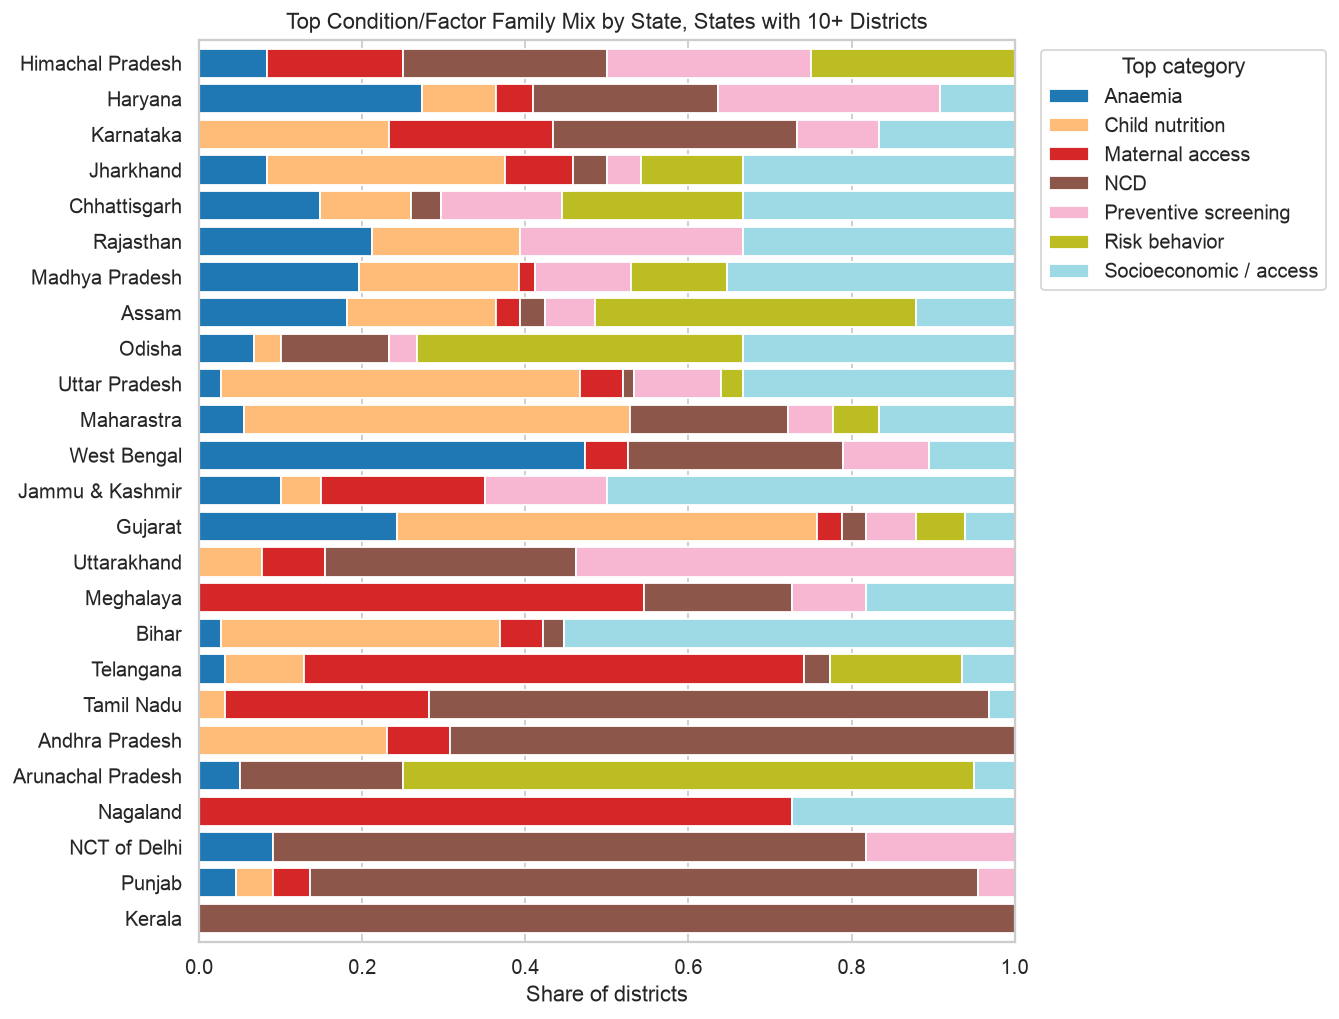

In [12]:
top_condition_counts = (
    top_conditions_by_district["top_condition_or_factor"]
    .value_counts()
    .rename_axis("condition_or_factor")
    .reset_index(name="districts")
)
top_condition_counts["category"] = top_condition_counts["condition_or_factor"].map(
    spec_df.set_index("condition")["category"]
)

fig, ax = plt.subplots(figsize=(10, 6.8))
plot_counts = top_condition_counts.head(15).sort_values("districts", ascending=True)
sns.barplot(
    data=plot_counts,
    y="condition_or_factor",
    x="districts",
    hue="category",
    dodge=False,
    ax=ax,
)
ax.set_title("Most Common Top Condition/Factor Across Districts")
ax.set_xlabel("Districts where this is the strongest relative issue")
ax.set_ylabel("")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt="%d")
plt.tight_layout()
plt.show()

state_category_mix = (
    top_conditions_by_district.groupby(["state_clean", "top_category"])
    .size()
    .rename("districts")
    .reset_index()
)
state_counts_for_mix = top_conditions_by_district["state_clean"].value_counts()
larger_states = state_counts_for_mix[state_counts_for_mix >= 10].index
state_category_mix = state_category_mix[state_category_mix["state_clean"].isin(larger_states)].copy()
state_category_mix["share"] = state_category_mix["districts"] / state_category_mix.groupby("state_clean")["districts"].transform("sum")

mix_pivot = (
    state_category_mix.pivot(index="state_clean", columns="top_category", values="share")
    .fillna(0)
    .loc[larger_states]
)
mix_pivot = mix_pivot.loc[mix_pivot.max(axis=1).sort_values(ascending=False).index]

ax = mix_pivot.plot(kind="barh", stacked=True, figsize=(10.5, 8), width=0.82, colormap="tab20")
ax.set_title("Top Condition/Factor Family Mix by State, States with 10+ Districts")
ax.set_xlabel("Share of districts")
ax.set_ylabel("")
ax.legend(title="Top category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 8. Aggregate impact / disaster proxy

The dataset does not include downstream outcomes such as mortality,
admissions, costs, or verified facility capacity. So the notebook cannot
train a causal model of what is truly most disastrous.

As a practical hackathon proxy, each condition/factor is scored by:

`impact_proxy = mean(district burden_or_gap_percent * district severity_percentile)`

This rewards indicators that are both widespread in raw percentage terms
and severe relative to other districts. It also reports how often a metric
is the top issue in a district and how many districts are in the top
decile of severity.


,rank,condition_or_factor,category,impact_proxy,mean_burden_or_gap_pct,p90_burden_or_gap_pct,districts_top_issue,districts_high_severity
0,1,Low breast exam,Preventive screening,50.0,99.3,100.0,9,0
1,2,Low oral cancer exam,Preventive screening,50.0,99.3,100.0,19,0
2,3,Low cervical screening,Preventive screening,49.8,98.4,100.0,35,109
3,4,Poor child diet,Child nutrition,46.1,88.1,96.0,51,65
4,5,Low health insurance,Socioeconomic / access,36.5,59.8,86.8,42,71
5,6,Child anaemia,Anaemia,36.3,65.8,78.7,38,72
6,7,Low women 10+ yrs schooling,Socioeconomic / access,33.9,59.7,77.0,26,72
7,8,Women anaemia,Anaemia,31.3,55.9,70.4,31,72
8,9,Low clean cooking fuel,Socioeconomic / access,29.9,45.9,75.9,23,72
9,10,Men tobacco use,Risk behavior,24.3,40.6,56.9,17,72


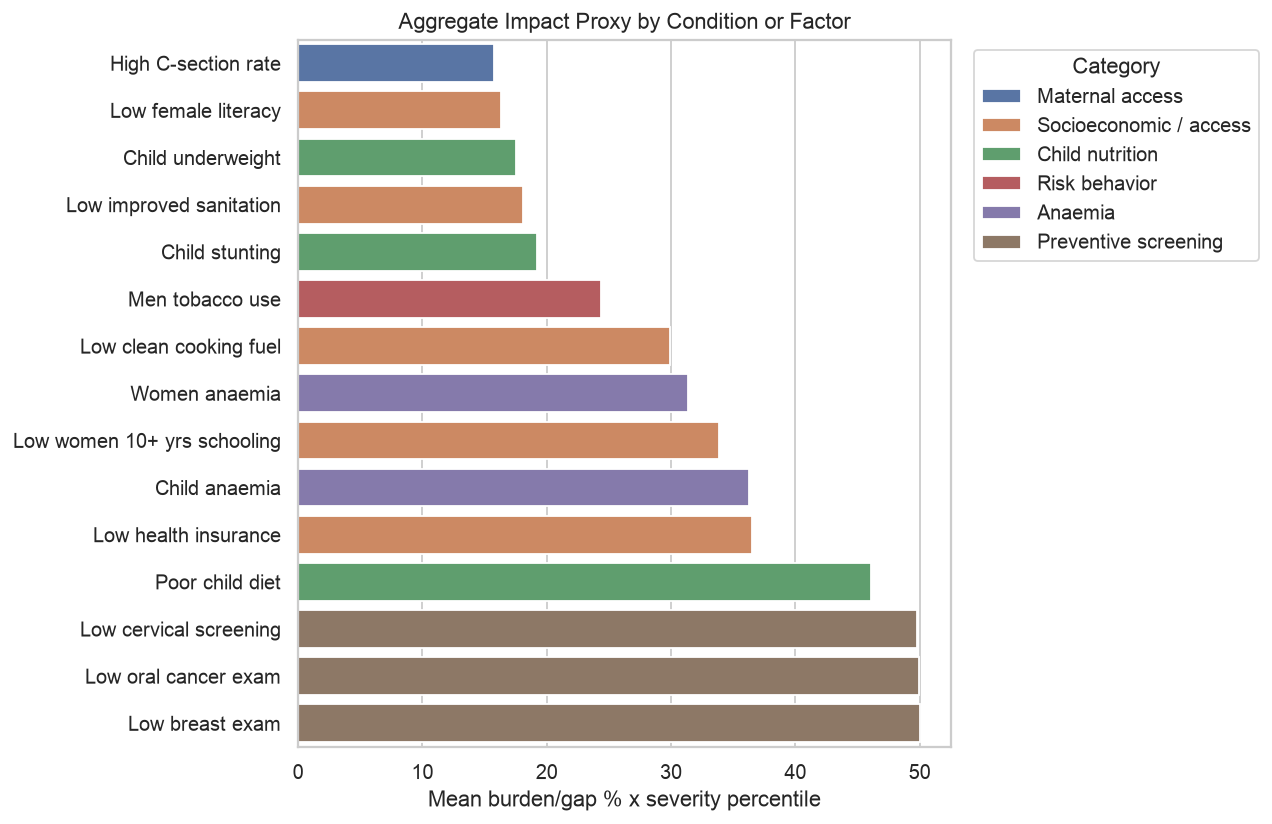

In [13]:
impact_rows = []
for spec in condition_specs:
    label = spec["condition"]
    burden = burden_matrix[label]
    severity = severity_matrix[label]
    impact_rows.append(
        {
            "condition_or_factor": label,
            "category": spec["category"],
            "direction": spec["direction"],
            "mean_burden_or_gap_pct": burden.mean(),
            "median_burden_or_gap_pct": burden.median(),
            "p90_burden_or_gap_pct": burden.quantile(0.90),
            "mean_severity_percentile": severity.mean(),
            "p90_severity_percentile": severity.quantile(0.90),
            "districts_top_issue": int((top_conditions_by_district["top_condition_or_factor"] == label).sum()),
            "districts_high_severity": int((severity >= 0.90).sum()),
            "impact_proxy": (burden * severity).mean(),
        }
    )

impact_summary = pd.DataFrame(impact_rows).sort_values("impact_proxy", ascending=False).reset_index(drop=True)
impact_summary["rank"] = np.arange(1, len(impact_summary) + 1)

display(
    impact_summary[
        [
            "rank",
            "condition_or_factor",
            "category",
            "impact_proxy",
            "mean_burden_or_gap_pct",
            "p90_burden_or_gap_pct",
            "districts_top_issue",
            "districts_high_severity",
        ]
    ]
    .head(15)
    .style.format(
        {
            "impact_proxy": "{:.1f}",
            "mean_burden_or_gap_pct": "{:.1f}",
            "p90_burden_or_gap_pct": "{:.1f}",
        }
    )
)

fig, ax = plt.subplots(figsize=(10, 6.5))
impact_plot = impact_summary.head(15).sort_values("impact_proxy", ascending=True)
sns.barplot(
    data=impact_plot,
    y="condition_or_factor",
    x="impact_proxy",
    hue="category",
    dodge=False,
    ax=ax,
)
ax.set_title("Aggregate Impact Proxy by Condition or Factor")
ax.set_xlabel("Mean burden/gap % x severity percentile")
ax.set_ylabel("")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


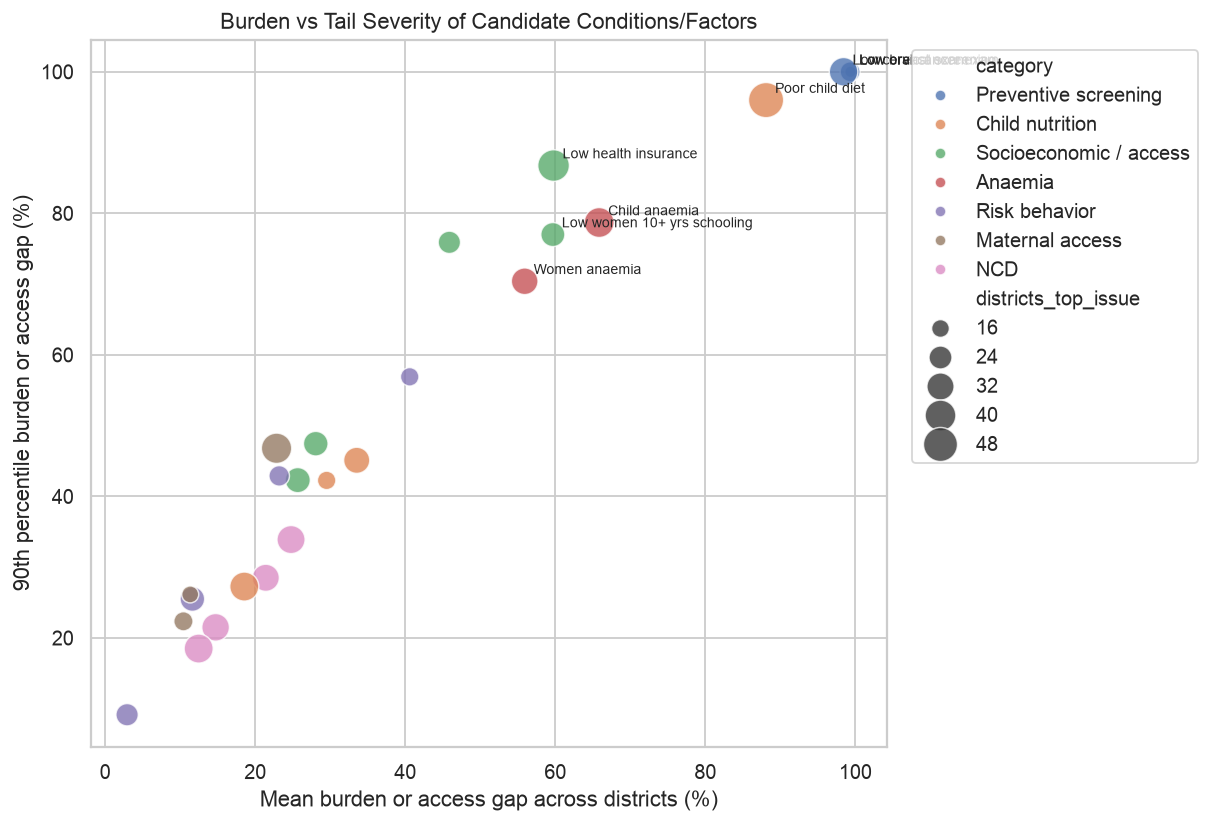

,category,mean_impact_proxy,max_impact_proxy,total_top_issue_districts,total_high_severity_districts
0,Preventive screening,49.9,50.0,63,109
1,Anaemia,33.8,36.3,69,144
2,Socioeconomic / access,26.9,36.5,146,358
3,Child nutrition,23.5,46.1,134,279
4,Risk behavior,12.7,24.3,87,287
5,Maternal access,10.7,15.7,72,213
6,NCD,10.7,14.3,135,285


In [14]:
fig, ax = plt.subplots(figsize=(9.5, 6.5))
sns.scatterplot(
    data=impact_summary,
    x="mean_burden_or_gap_pct",
    y="p90_burden_or_gap_pct",
    size="districts_top_issue",
    hue="category",
    sizes=(40, 380),
    alpha=0.78,
    ax=ax,
)
ax.set_title("Burden vs Tail Severity of Candidate Conditions/Factors")
ax.set_xlabel("Mean burden or access gap across districts (%)")
ax.set_ylabel("90th percentile burden or access gap (%)")

for _, row in impact_summary.head(8).iterrows():
    ax.annotate(
        row["condition_or_factor"],
        (row["mean_burden_or_gap_pct"], row["p90_burden_or_gap_pct"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

category_impact = (
    impact_summary.groupby("category")
    .agg(
        mean_impact_proxy=("impact_proxy", "mean"),
        max_impact_proxy=("impact_proxy", "max"),
        total_top_issue_districts=("districts_top_issue", "sum"),
        total_high_severity_districts=("districts_high_severity", "sum"),
    )
    .sort_values("mean_impact_proxy", ascending=False)
    .reset_index()
)
display(category_impact.style.format({"mean_impact_proxy": "{:.1f}", "max_impact_proxy": "{:.1f}"}))


## 9. Distribution shapes: Gaussian or not?

Most NFHS columns are bounded percentages, so true Gaussian behavior is
unlikely. The diagnostics below use skew, excess kurtosis, and a
Jarque-Bera-style normality proxy computed directly from skew/kurtosis.
That avoids adding SciPy as a notebook dependency.

Rule of thumb used here:

- `roughly symmetric`: absolute skew below 0.5.
- `right-skewed`: long high-value tail.
- `left-skewed / ceiling-heavy`: many districts near high coverage.
- `heavy-tailed or peaked`: excess kurtosis above 1.


In [15]:
from statistics import NormalDist

distribution_cols = {
    "Institutional births": "institutional_birth_5y_pct",
    "C-section deliveries": "births_delivered_by_csection_5y_pct",
    "Full vaccination": "child_12_23m_fully_vaccinated_based_on_information_from_vax_pct",
    "Adequate child diet": "total_child_6_23m_receiving_an_adequate_diet16_17_pct",
    "U5 stunted": "child_u5_who_are_stunted_height_for_age_18_pct",
    "Women anaemic": "all_w15_49_who_are_anaemic_pct",
    "Women high BP": "w15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct",
    "Men high BP": "m15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct",
    "Cervical screening": "women_age_30_49_years_ever_undergone_a_cervical_screen_pct",
    "Men tobacco": "m15_plus_who_use_any_kind_of_tobacco_pct",
    "Low clean cooking fuel gap": "households_using_clean_fuel_for_cooking_pct",
    "Health-need score": "health_need_score",
}

dist_rows = []
for label, col in distribution_cols.items():
    x = health[col].dropna()
    if label == "Low clean cooking fuel gap":
        x = 100 - x
    n = len(x)
    skew = x.skew()
    excess_kurtosis = x.kurt()
    jb_stat = (n / 6) * (skew**2 + (excess_kurtosis**2 / 4))
    jb_pvalue_proxy = np.exp(-jb_stat / 2)  # chi-square survival for df=2
    if abs(skew) < 0.5:
        shape = "roughly symmetric"
    elif skew > 0.5:
        shape = "right-skewed"
    else:
        shape = "left-skewed / ceiling-heavy"
    if excess_kurtosis > 1:
        shape += "; heavy-tailed/peaked"
    dist_rows.append(
        {
            "indicator": label,
            "n": n,
            "mean": x.mean(),
            "median": x.median(),
            "std": x.std(),
            "skew": skew,
            "excess_kurtosis": excess_kurtosis,
            "jb_pvalue_proxy": jb_pvalue_proxy,
            "shape_read": shape,
        }
    )

distribution_summary = pd.DataFrame(dist_rows).sort_values("jb_pvalue_proxy")
display(
    distribution_summary.style.format(
        {
            "mean": "{:.1f}",
            "median": "{:.1f}",
            "std": "{:.1f}",
            "skew": "{:.2f}",
            "excess_kurtosis": "{:.2f}",
            "jb_pvalue_proxy": "{:.2e}",
        }
    )
)


,indicator,n,mean,median,std,skew,excess_kurtosis,jb_pvalue_proxy,shape_read
8,Cervical screening,706,1.6,0.6,2.8,3.60,15.85,0.00e+00,right-skewed; heavy-tailed/peaked
0,Institutional births,706,88.7,92.2,12.0,-1.96,5.07,9.13e-263,left-skewed / ceiling-heavy; heavy-tailed/peaked
1,C-section deliveries,706,22.8,18.6,16.0,1.15,0.94,2.04e-40,right-skewed
3,Adequate child diet,654,11.9,10.6,7.1,0.91,0.81,2.86e-24,right-skewed
10,Low clean cooking fuel gap,706,45.9,49.5,24.2,-0.22,-1.16,1.76e-10,roughly symmetric
6,Women high BP,706,21.4,21.0,5.2,0.54,0.41,3.43e-09,right-skewed
7,Men high BP,706,24.8,24.4,6.8,0.52,0.20,7.76e-08,right-skewed
2,Full vaccination,361,82.6,83.6,9.7,-0.66,0.39,6.79e-07,left-skewed / ceiling-heavy
5,Women anaemic,706,55.9,57.2,11.9,-0.40,0.29,2.19e-05,roughly symmetric
9,Men tobacco,706,40.6,42.5,14.1,-0.16,-0.50,5.37e-03,roughly symmetric


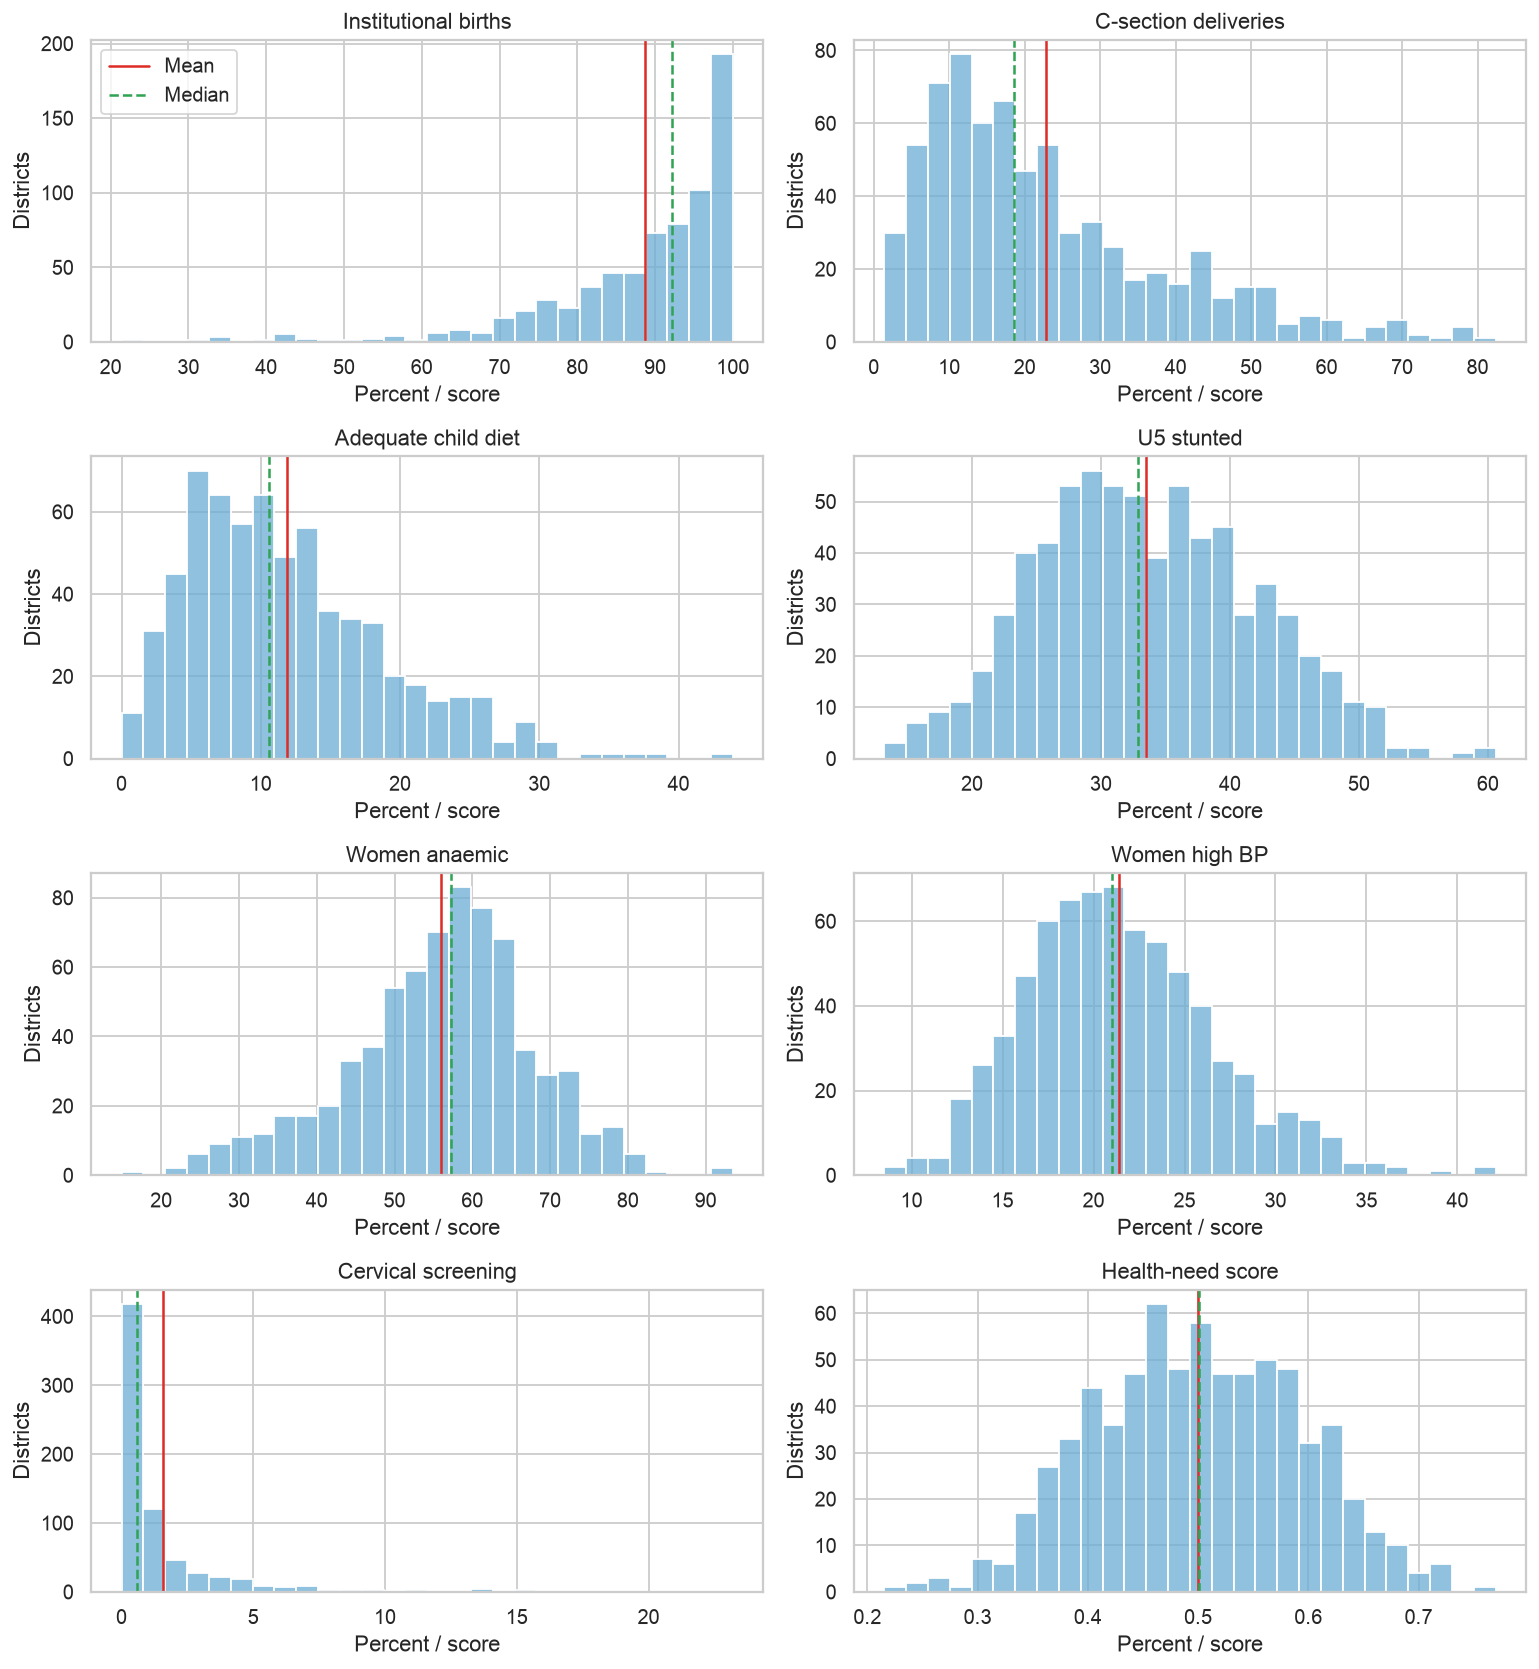

In [16]:
hist_cols = [
    "Institutional births",
    "C-section deliveries",
    "Adequate child diet",
    "U5 stunted",
    "Women anaemic",
    "Women high BP",
    "Cervical screening",
    "Health-need score",
]

fig, axes = plt.subplots(4, 2, figsize=(12, 13))
for ax, label in zip(axes.flat, hist_cols):
    col = distribution_cols[label]
    values = health[col].dropna()
    sns.histplot(values, bins=28, ax=ax, color="#6baed6")
    ax.axvline(values.mean(), color="#de2d26", linewidth=1.4, label="Mean")
    ax.axvline(values.median(), color="#31a354", linewidth=1.4, linestyle="--", label="Median")
    ax.set_title(label)
    ax.set_xlabel("Percent / score")
    ax.set_ylabel("Districts")
axes.flat[0].legend()
plt.tight_layout()
plt.show()


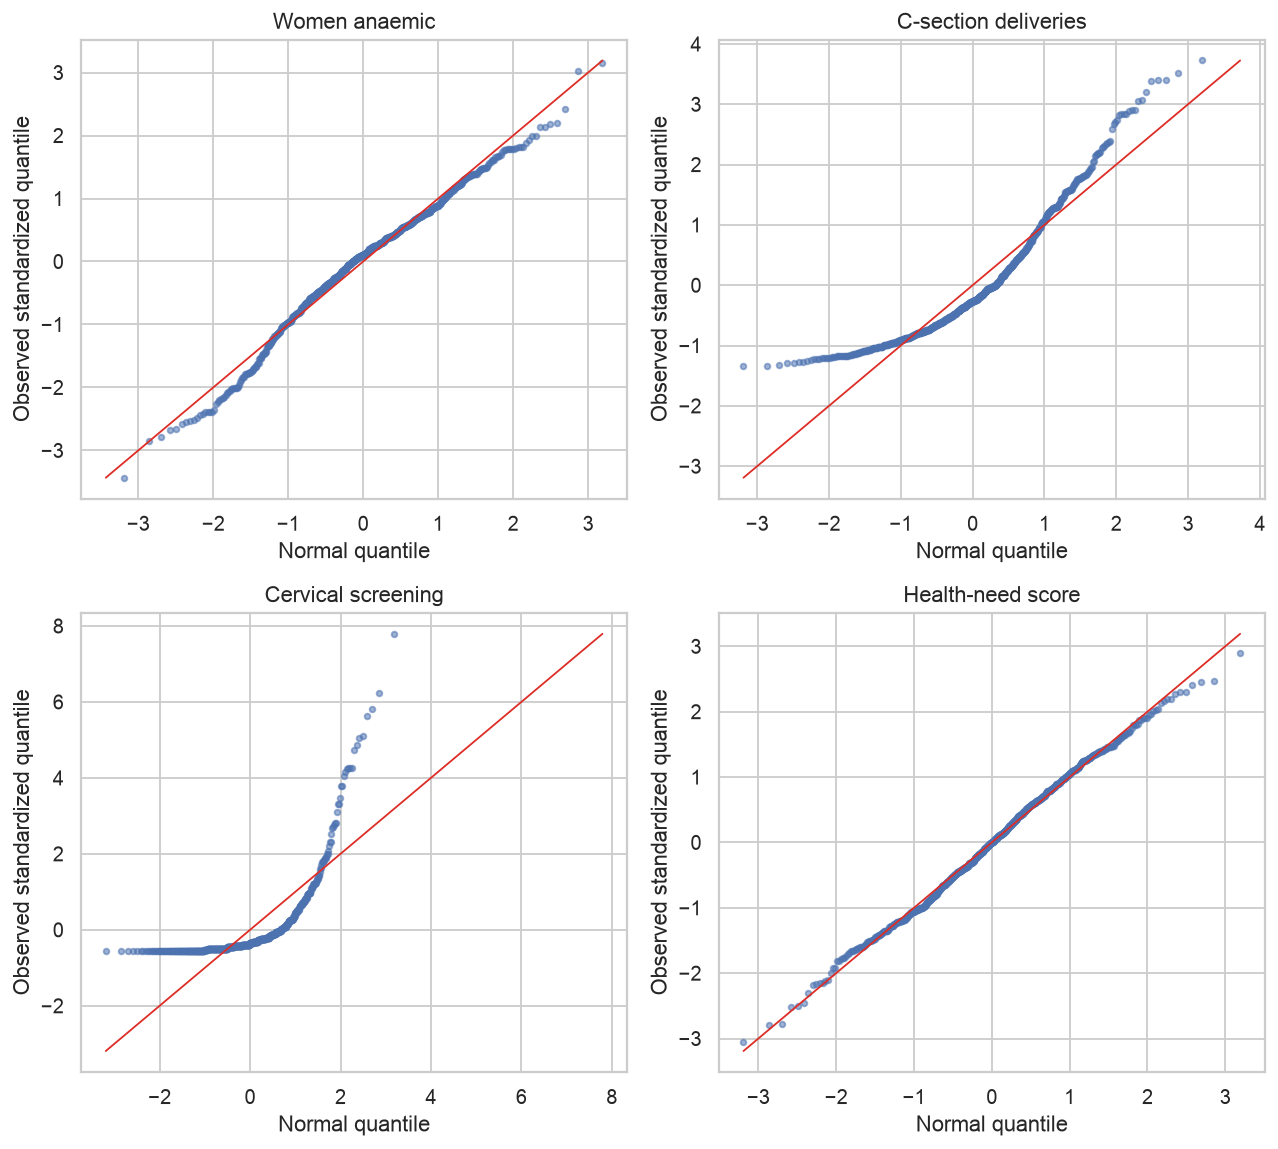

In [17]:
qq_targets = {
    "Women anaemic": "all_w15_49_who_are_anaemic_pct",
    "C-section deliveries": "births_delivered_by_csection_5y_pct",
    "Cervical screening": "women_age_30_49_years_ever_undergone_a_cervical_screen_pct",
    "Health-need score": "health_need_score",
}

normal = NormalDist()
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, (label, col) in zip(axes.flat, qq_targets.items()):
    x = health[col].dropna().sort_values().to_numpy()
    n = len(x)
    probs = (np.arange(1, n + 1) - 0.5) / n
    theoretical = np.array([normal.inv_cdf(p) for p in probs])
    sample_z = (x - x.mean()) / x.std(ddof=1)
    ax.scatter(theoretical, sample_z, s=10, alpha=0.55)
    line_min = min(theoretical.min(), sample_z.min())
    line_max = max(theoretical.max(), sample_z.max())
    ax.plot([line_min, line_max], [line_min, line_max], color="#de2d26", linewidth=1)
    ax.set_title(label)
    ax.set_xlabel("Normal quantile")
    ax.set_ylabel("Observed standardized quantile")
plt.tight_layout()
plt.show()


## 10. Qualitative synthesis for doctors and resource planners

The district indicators can help doctors move from reactive care to
proactive deployment. The dataset does not say whether a specific facility
is good or bad; it says what the surrounding district population appears
to need. That makes it useful for deciding where to send screening camps,
mobile clinical teams, health educators, medication stock, diagnostics, or
referral support.

Practical interpretation for doctors:

- **Preventive screening gaps** point to places where mobile cervical,
  breast, and oral cancer screening can create immediate public-health
  value. These are not rare outliers; the aggregate proxy shows screening
  is weak almost everywhere, so prioritization should combine screening
  gaps with broader health need and on-the-ground feasibility.
- **Child nutrition and anaemia signals** suggest where pediatric,
  maternal, nutrition, iron/folate, and community-health-worker programs
  should be paired with routine care.
- **NCD signals** such as high blood pressure and high blood sugar suggest
  where doctors should bring chronic-disease screening, follow-up
  protocols, medication continuity plans, and referral networks.
- **Maternal access gaps** help identify places where ANC, skilled birth
  attendance, referral transport, and public-facility delivery pathways
  matter more than one-off clinical visits.
- **Socioeconomic/access indicators** are not medical conditions, but they
  explain why clinical interventions may fail without insurance navigation,
  sanitation, education, fuel, or local partner support.

For deployment decisions, use this as a triage map: pick districts with
high need, severe gaps, and clear intervention fit; then validate locally
before sending staff or supplies.


In [18]:
doctor_playbook = pd.DataFrame(
    [
        {
            "Need pattern": "Low preventive screening",
            "What doctors can infer": "Potentially large undetected cancer-screening need; awareness and access may be low.",
            "Resource response": "Mobile cervical, breast, and oral cancer screening; HPV/cervical workflows; oral exams tied to tobacco counseling; referral follow-up.",
        },
        {
            "Need pattern": "Child anaemia / poor diet / undernutrition",
            "What doctors can infer": "Clinical need is likely tied to nutrition, maternal health, and household constraints.",
            "Resource response": "Pediatric outreach, nutrition counseling, anaemia testing, iron/folate linkage, growth-monitoring camps, CHW follow-up.",
        },
        {
            "Need pattern": "High BP / high blood sugar",
            "What doctors can infer": "Chronic disease screening and continuity of care may be more valuable than episodic specialty visits.",
            "Resource response": "BP/glucose camps, repeat follow-up days, medication stock planning, referral pathways, patient registries.",
        },
        {
            "Need pattern": "Low institutional births / skilled attendance",
            "What doctors can infer": "Maternal care access, referral transport, or facility trust may be limiting safe delivery.",
            "Resource response": "ANC outreach, birth planning, obstetric referral coordination, transport partnerships, public-facility linkage.",
        },
        {
            "Need pattern": "Low insurance / sanitation / literacy / clean fuel",
            "What doctors can infer": "Non-clinical barriers may reduce care uptake and adherence.",
            "Resource response": "Partner with public health teams, NGOs, and local government; add benefits navigation and health education.",
        },
    ]
)
display(doctor_playbook)

screening_cols = {
    "Cervical screening": "women_age_30_49_years_ever_undergone_a_cervical_screen_pct",
    "Breast exam": "women_age_30_49_years_ever_undergone_a_breast_exam_pct",
    "Oral cancer exam": "women_age_30_49_years_ever_undergone_an_oral_cancer_exam_pct",
}

preventive = health[["district_clean", "state_clean", "health_need_score", *screening_cols.values()]].copy()
preventive = preventive.rename(columns={v: k for k, v in screening_cols.items()})
preventive["preventive_screening_avg_pct"] = preventive[list(screening_cols)].mean(axis=1)
preventive["preventive_screening_gap_pct"] = 100 - preventive["preventive_screening_avg_pct"]
preventive["screening_gap_severity_percentile"] = preventive["preventive_screening_gap_pct"].rank(pct=True)

# Observed facility rows are a hackathon-data coverage proxy, not true facility supply.
facility_counts = facilities.dropna(subset=["state_ut", "district_name"]).copy()
facility_counts["facility_health_key"] = (
    facility_counts["state_ut"].map(normalize_state)
    + "|"
    + facility_counts["district_name"].astype(str).str.strip().map(normalize_text)
)
facility_counts = facility_counts.groupby("facility_health_key")["unique_id"].nunique().rename("observed_facility_rows").reset_index()
preventive["health_key"] = preventive["state_clean"].map(normalize_state) + "|" + preventive["district_clean"].map(normalize_text)
preventive = preventive.merge(facility_counts, left_on="health_key", right_on="facility_health_key", how="left")
preventive["observed_facility_rows"] = preventive["observed_facility_rows"].fillna(0).astype(int)
preventive["low_observed_facility_coverage_percentile"] = (-preventive["observed_facility_rows"]).rank(pct=True)

preventive = preventive.merge(
    top_conditions_by_district[
        ["district_clean", "state_clean", "top_condition_or_factor", "top_category", "top_severity_percentile"]
    ],
    on=["district_clean", "state_clean"],
    how="left",
)
preventive["doctor_resource_priority_score"] = (
    0.50 * preventive["screening_gap_severity_percentile"]
    + 0.30 * preventive["health_need_score"]
    + 0.20 * preventive["low_observed_facility_coverage_percentile"]
)

worst_screening = preventive.sort_values(
    ["preventive_screening_avg_pct", "health_need_score"], ascending=[True, False]
).head(25)

doctor_priority = preventive.sort_values(
    ["doctor_resource_priority_score", "screening_gap_severity_percentile", "health_need_score"],
    ascending=False,
).head(20)

display(
    worst_screening[
        [
            "district_clean",
            "state_clean",
            "Cervical screening",
            "Breast exam",
            "Oral cancer exam",
            "preventive_screening_avg_pct",
            "preventive_screening_gap_pct",
            "health_need_score",
            "top_condition_or_factor",
        ]
    ].style.format(
        {
            "Cervical screening": "{:.1f}",
            "Breast exam": "{:.1f}",
            "Oral cancer exam": "{:.1f}",
            "preventive_screening_avg_pct": "{:.1f}",
            "preventive_screening_gap_pct": "{:.1f}",
            "health_need_score": "{:.3f}",
        }
    )
)

display(
    doctor_priority[
        [
            "district_clean",
            "state_clean",
            "doctor_resource_priority_score",
            "preventive_screening_gap_pct",
            "health_need_score",
            "observed_facility_rows",
            "top_condition_or_factor",
            "top_category",
        ]
    ].style.format(
        {
            "doctor_resource_priority_score": "{:.3f}",
            "preventive_screening_gap_pct": "{:.1f}",
            "health_need_score": "{:.3f}",
        }
    )
)


,Need pattern,What doctors can infer,Resource response
0,Low preventive screening,Potentially large undetected cancer-screening ...,"Mobile cervical, breast, and oral cancer scree..."
1,Child anaemia / poor diet / undernutrition,"Clinical need is likely tied to nutrition, mat...","Pediatric outreach, nutrition counseling, anae..."
2,High BP / high blood sugar,Chronic disease screening and continuity of ca...,"BP/glucose camps, repeat follow-up days, medic..."
3,Low institutional births / skilled attendance,"Maternal care access, referral transport, or f...","ANC outreach, birth planning, obstetric referr..."
4,Low insurance / sanitation / literacy / clean ...,Non-clinical barriers may reduce care uptake a...,"Partner with public health teams, NGOs, and lo..."


,district_clean,state_clean,Cervical screening,Breast exam,Oral cancer exam,preventive_screening_avg_pct,preventive_screening_gap_pct,health_need_score,top_condition_or_factor
78,Katihar,Bihar,0.0,0.0,0.0,0.0,100.0,0.770,Child underweight
690,Uttar Dinajpur,West Bengal,0.0,0.0,0.0,0.0,100.0,0.730,Women anaemia
234,Pakur,Jharkhand,0.0,0.0,0.0,0.0,100.0,0.730,Low women 10+ yrs schooling
165,Kheda,Gujarat,0.0,0.0,0.0,0.0,100.0,0.715,Poor child diet
416,Wokha,Nagaland,0.0,0.0,0.0,0.0,100.0,0.705,Low institutional births
72,Sitamarhi,Bihar,0.0,0.0,0.0,0.0,100.0,0.704,Child stunting
104,Jamui,Bihar,0.0,0.0,0.0,0.0,100.0,0.701,Low improved sanitation
703,Paschim Medinipur,West Bengal,0.0,0.0,0.0,0.0,100.0,0.690,Women anaemia
31,Longding,Arunachal Pradesh,0.0,0.0,0.0,0.0,100.0,0.678,Men alcohol use
460,Kalahandi,Odisha,0.0,0.0,0.0,0.0,100.0,0.670,Low cervical screening


,district_clean,state_clean,doctor_resource_priority_score,preventive_screening_gap_pct,health_need_score,observed_facility_rows,top_condition_or_factor,top_category
690,Uttar Dinajpur,West Bengal,0.870,100.0,0.730,0,Women anaemia,Anaemia
234,Pakur,Jharkhand,0.870,100.0,0.730,0,Low women 10+ yrs schooling,Socioeconomic / access
416,Wokha,Nagaland,0.863,100.0,0.705,0,Low institutional births,Maternal access
104,Jamui,Bihar,0.862,100.0,0.701,0,Low improved sanitation,Socioeconomic / access
703,Paschim Medinipur,West Bengal,0.858,100.0,0.690,0,Women anaemia,Anaemia
31,Longding,Arunachal Pradesh,0.855,100.0,0.678,0,Men alcohol use,Risk behavior
418,Phek,Nagaland,0.849,100.0,0.659,0,Low institutional births,Maternal access
244,Jamtara,Jharkhand,0.847,100.0,0.653,0,Women anaemia,Anaemia
122,Balrampur,Chhattisgarh,0.847,100.0,0.651,0,Low clean cooking fuel,Socioeconomic / access
344,Alirajpur,Madhya Pradesh,0.840,100.0,0.630,0,Low female literacy,Socioeconomic / access


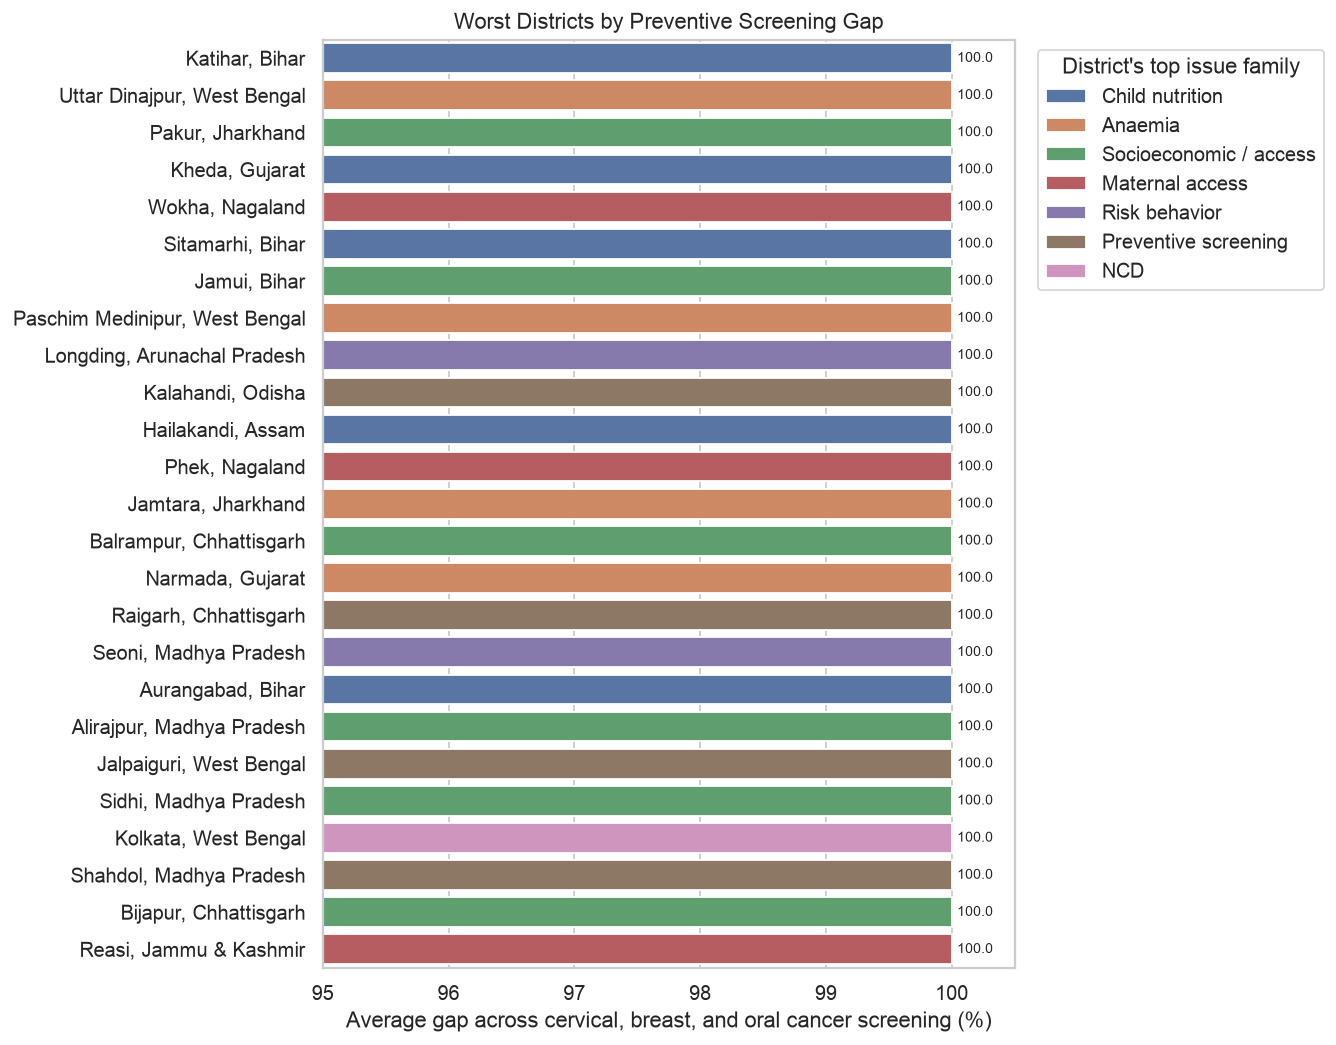

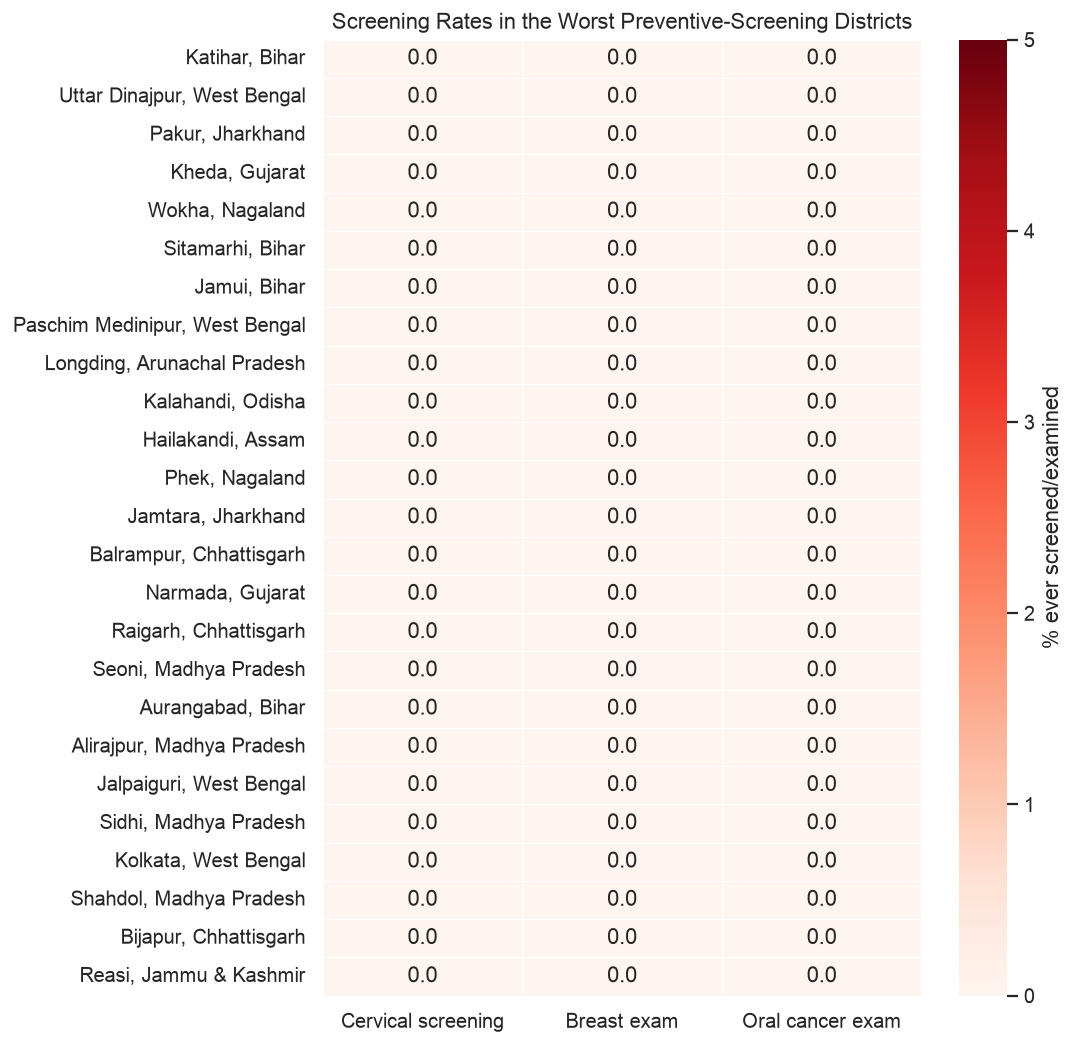

In [19]:
plot_worst = worst_screening.sort_values("preventive_screening_gap_pct", ascending=True).copy()
plot_worst["district_label"] = plot_worst["district_clean"] + ", " + plot_worst["state_clean"]

fig, ax = plt.subplots(figsize=(10.5, 8.2))
sns.barplot(
    data=plot_worst,
    y="district_label",
    x="preventive_screening_gap_pct",
    hue="top_category",
    dodge=False,
    ax=ax,
)
ax.set_title("Worst Districts by Preventive Screening Gap")
ax.set_xlabel("Average gap across cervical, breast, and oral cancer screening (%)")
ax.set_ylabel("")
ax.set_xlim(95, 100.5)
ax.legend(title="District's top issue family", bbox_to_anchor=(1.02, 1), loc="upper left")
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt="%.1f", fontsize=8)
plt.tight_layout()
plt.show()

heatmap_data = (
    worst_screening.set_index(worst_screening["district_clean"] + ", " + worst_screening["state_clean"])[
        ["Cervical screening", "Breast exam", "Oral cancer exam"]
    ]
    .sort_values(["Cervical screening", "Breast exam", "Oral cancer exam"])
)

fig, ax = plt.subplots(figsize=(8.5, 8.2))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    vmin=0,
    vmax=5,
    linewidths=0.35,
    cbar_kws={"label": "% ever screened/examined"},
    ax=ax,
)
ax.set_title("Screening Rates in the Worst Preventive-Screening Districts")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


**How this should inform travel or staffing decisions:** prioritize
districts where a specific intervention matches a high-severity gap. For
example, a mobile preventive-screening team should start with districts
near the top of the preventive-screening gap table, then use the broader
health-need score and local facility/partner information to choose an
executable route. A chronic-disease team would instead weight high BP and
blood-sugar districts more heavily, while maternal/child teams should focus
on anaemia, nutrition, ANC, and skilled delivery indicators.

The proactive value is not that the dataset tells a doctor exactly where
to go tomorrow. It narrows the field: which districts need validation,
which services to pack, which referral partners to line up, and which
follow-up programs are likely to matter after the first visit.


## 11. Takeaways for the hackathon app

- Treat these indicators as district context, never as facility facts.
- Preserve `join_strategy`, `join_confidence`, and `join_uncertainty_reason`
  wherever facility rankings or recommendations use district health context.
- Build or import a state/district crosswalk before using the table in
  production-like flows.
- Useful app signals include maternal access gaps, child nutrition burden,
  anaemia, adult NCD burden, preventive screening gaps, and insurance or
  education context.
- Any official estimate should go back to NFHS documentation and survey
  weights. This notebook uses unweighted district summaries for exploratory
  planning.
